In [4]:
import pdb
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pylab as pylab
import cartopy
import cartopy.crs as ccrs
import pickle as pkl
import glob
from metpy import calc
from metpy.units import units
import matplotlib.patches as patches
from scipy import stats
from endgame import hist2d

from shared.paths import load_paths
paths = load_paths()

pylab.rcParams['figure.figsize'] = (50., 50.)
%matplotlib inline

In [3]:
cd ..

/home/users/cornkle/pythonWorkspace/proj_CEH


In [5]:
def calc_div(da):
    u = units.Quantity(da['u_srfc'].values, 'm/s')
    v = units.Quantity(da['v_srfc'].values, 'm/s')
    
    dx = units.Quantity(4400, 'm')
    div = calc.divergence(u,v, dx=dx, dy=dx)
    # vort = calc.shearing_deformation(u,v, dx, dx)
    da_div = da['sh'].copy(deep=True)
    da_div.values = div
    
    return da_div

In [6]:
def calc_div_mid(da):
    u = units.Quantity(da['u_mid'].values, 'm/s')
    v = units.Quantity(da['v_mid'].values, 'm/s')
    
    dx = units.Quantity(4400, 'm')
    div = calc.divergence(u,v, dx=dx, dy=dx)
    # vort = calc.shearing_deformation(u,v, dx, dx)
    da_div = da['sh'].copy(deep=True)
    da_div.values = div
    
    return da_div

In [7]:
def calc_theta(da):    
    p = units.Quantity(925, 'hPa')
    t = units.Quantity(da['t_srfc'].values+273.15, 'K')
    q = units.Quantity(da['q_srfc'].values/1000, 'kg/kg')
    
    p_up = units.Quantity(650, 'hPa')
    t_up = units.Quantity(da['t_mid'].values+273.15, 'K')
    
    thetaes_up = np.array(calc.saturation_equivalent_potential_temperature(p_up,t_up))
    
    dew = calc.dewpoint_from_specific_humidity(p,t,q)
    thetae_down = np.array(calc.equivalent_potential_temperature(p,t,dew))
     
    thetae = thetae_down #-thetaes_up 
    
    da_theta = da['sh'].copy(deep=True)
    da_theta.values = thetae
    
  #  ipdb.set_trace()
    
    return da_theta

In [8]:
# lahist = pd.read_csv(paths.cp4_tables + '/hist_table_1700_inclStormChar_anom_200km.csv', index_col=0).transpose()
# lafut =  pd.read_csv(paths.cp4_tables + '/fut_table_1700_inclStormChar_anom_200km.csv', index_col=0).transpose()

In [9]:
# for tag in [('historical', 'hist'), ('future', 'fut')]:

#     fh = glob.glob('/media/ck/LStorage/global_water/CP_models/MCS_files/MODELS/CP4_box/CP4_allHours_'+tag[0]+'_5000km2_-50_WAf_box_v2/*.nc')
#     dic = {}
#     dummy = xr.open_dataset(fh[0])
#     for vn in dummy.data_vars:
#         dic[vn] = []
#     for v in varsi:
#         dic[v] = []

#     for ffh in fh:
#         ds = xr.open_dataset(ffh)
#         outt = ds['lw_out_PBLtop'].values
#         outp = ds['lsRain'].values
#         outq = ds['q_srfc'].values
#         outp_noon = ds['lsRain_noon'].values

#         t_thresh = -50
#         mask = np.isfinite(outq) & (outp==0)

#         out['area'] = np.sum((outt<=t_thresh))
#         out['area-60'] = np.sum((outt <= -60))
#         out['area-70'] = np.sum((outt <= -70))
#         out['area-80'] = np.sum((outt <= -80))
        
#         out['lon'] = ds.minlon
#         out['lat'] = ds.minlat
#         out['hour'] = ds['time.hour'].item()
#         out['month'] = ds['time.month'].item()
#         out['year'] = ds['time.year'].item()
#         out['day'] = ds['time.day'].item()

#         maxpos = np.unravel_index(np.nanargmax(outp), outp.shape)
#         minpos = np.unravel_index(np.nanargmin(outt), outt.shape)

#             for vn in ds.data_vars:

#                 da = ds[vn].sel(latitude=slice(-11,11), longitude=slice(-11,11)).count(['longitude','latitude'])
#                 #ipdb.set_trace()
#                 if da > 0.25*(22*22):
#                     da =  float(ds[vn].sel(latitude=slice(-11,11), longitude=slice(-11,11)).mean(['longitude','latitude']).values)
#                 else:
#                     da = np.nan

#                 dic[vn].append(float(da))
#     df = pd.DataFrame.from_dict(dic, orient="index")
#     df.to_csv('/home/ck/DIR/cornkle/data/LMCS/MCS_files/CP4_box/'+tag[1]+'_table_1700_inclStormChar.csv')

# lhist = pd.read_csv(paths.cp4_tables + '/hist_table_1700_inclStormChar_200km.csv', index_col=0).transpose()
# lfut =  pd.read_csv(paths.cp4_tables + '//fut_table_1700_inclStormChar_200km.csv', index_col=0).transpose()

In [10]:
# fh = glob.glob(cnst.lmcs_drive +'/CP_models/MCS_files/MODELS/CP4_box_anom/CP4_allHours_historical_5000km2_-50_WAf_box_anom_v2/*.nc')
# #ipdb.set_trace()
# dic = {}
# dummy = xr.open_dataset(fh[0])
# for vn in dummy.data_vars:
#     dic[vn] = []

# for ffh in fh:
#     ds = xr.open_dataset(ffh)
#     for vn in ds.data_vars:
        
#         da = ds[vn].sel(latitude=slice(-11,11), longitude=slice(-11,11)).count(['longitude','latitude'])
#         #ipdb.set_trace()
#         if da > 0.25*(22*22):
#             da =  float(ds[vn].sel(latitude=slice(-11,11), longitude=slice(-11,11)).mean(['longitude','latitude']).values)
#         else:
#             da = np.nan
        
#         dic[vn].append(float(da))
# df = pd.DataFrame.from_dict(dic, orient="index")
# df.to_csv('/home/ck/DIR/cornkle/data/LMCS/MCS_files/CP4_box/hist_table_anom_1700_inclStormChar.csv')

# ########

# fh = glob.glob(cnst.lmcs_drive +'/CP_models/MCS_files/MODELS/CP4_box_anom/CP4_allHours_future_5000km2_-50_WAf_box_anom_v2/*.nc')
# dic = {}
# dummy = xr.open_dataset(fh[0])
# for vn in dummy.data_vars:
#     dic[vn] = []

# for ffh in fh:
#     ds = xr.open_dataset(ffh)
#     for vn in ds.data_vars:
        
#         da = ds[vn].sel(latitude=slice(-11,11), longitude=slice(-11,11)).count(['longitude','latitude'])
#         #ipdb.set_trace()
#         if da > 0.25*(22*22):
#             da =  float(ds[vn].sel(latitude=slice(-11,11), longitude=slice(-11,11)).mean(['longitude','latitude']).values)
#         else:
#             da = np.nan
        
#         dic[vn].append(float(da))
# df = pd.DataFrame.from_dict(dic, orient="index")
# df.to_csv('/home/ck/DIR/cornkle/data/LMCS/MCS_files/CP4_box/fut_table_anom_1700_inclStormChar.csv')

In [11]:
lhist2 = pd.read_csv(paths.cp4_tables + '/hist_table_1700_inclStormChar_200km_div.csv', index_col=0).transpose()
lfut2 =  pd.read_csv(paths.cp4_tables + '/fut_table_1700_inclStormChar_200km_div.csv', index_col=0).transpose()

lhist = pd.read_csv(paths.cp4_2d + '/CP4_box_JASMIN/mean3h_v2/tables/hist_mean_table_JASMIN_3hmeansVersion.csv', index_col=0, low_memory=False).T
lfut = pd.read_csv(paths.cp4_2d + '/CP4_box_JASMIN/mean3h_v2/tables/fut_mean_table_JASMIN_3hmeansVersion.csv', index_col=0, low_memory=False).T

In [12]:
lahist2 = pd.read_csv(paths.cp4_tables + '/hist_table_1700_inclStormChar_anom_200km_div.csv', index_col=0).transpose()
lafut2=  pd.read_csv(paths.cp4_tables + '/fut_table_1700_inclStormChar_anom_200km_div.csv', index_col=0).transpose()

lahist = pd.read_csv(paths.cp4_2d + '/CP4_box_JASMIN/mean3h_v2/tables/hist_anom_table_JASMIN_3hmeansVersion.csv', index_col=0, low_memory=False).T
lafut = pd.read_csv(paths.cp4_2d + '/CP4_box_JASMIN/mean3h_v2/tables/fut_anom_table_JASMIN_3hmeansVersion.csv', index_col=0, low_memory=False).T

In [13]:
np.unique(lafut['hour'])

array(['17', '18', '19'], dtype=object)

In [17]:
list(lahist)

['tcwv_0.25deg',
 'sh_0.25deg',
 'lh_0.25deg',
 't2_0.25deg',
 'q2_0.25deg',
 'pblH_0.25deg',
 'shear_0.25deg',
 'u_mid_0.25deg',
 'u_srfc_0.25deg',
 'v_mid_0.25deg',
 'v_srfc_0.25deg',
 'q_mid_0.25deg',
 't_mid_0.25deg',
 't_srfc_0.25deg',
 'q_srfc_0.25deg',
 'geoH_srfc_0.25deg',
 'lsRain_noon_0.25deg',
 'lwout_noon_0.25deg',
 'SM_0.25deg',
 'lw_net_0.25deg',
 'sw_in_0.25deg',
 'sw_net_0.25deg',
 'u10_0.25deg',
 'v10_0.25deg',
 'tcwv_1deg',
 'sh_1deg',
 'lh_1deg',
 't2_1deg',
 'q2_1deg',
 'pblH_1deg',
 'shear_1deg',
 'u_mid_1deg',
 'u_srfc_1deg',
 'v_mid_1deg',
 'v_srfc_1deg',
 'q_mid_1deg',
 't_mid_1deg',
 't_srfc_1deg',
 'q_srfc_1deg',
 'geoH_srfc_1deg',
 'lsRain_noon_1deg',
 'lwout_noon_1deg',
 'SM_1deg',
 'lw_net_1deg',
 'sw_in_1deg',
 'sw_net_1deg',
 'u10_1deg',
 'v10_1deg',
 'tcwv_2deg',
 'sh_2deg',
 'lh_2deg',
 't2_2deg',
 'q2_2deg',
 'pblH_2deg',
 'shear_2deg',
 'u_mid_2deg',
 'u_srfc_2deg',
 'v_mid_2deg',
 'v_srfc_2deg',
 'q_mid_2deg',
 't_mid_2deg',
 't_srfc_2deg',
 'q_srfc_

In [197]:
for dat in [lahist, lafut, lhist, lfut, lahist2, lafut2, lhist2, lfut2]:
    for var in dat.keys():
        try:
            dat[var] = dat[var].astype(float)
        except:
            pass

In [198]:
lahist, lafut, lhist, lfut, lahist2, lafut2 = [df.copy() for df in (lahist, lafut, lhist, lfut,lahist2,lafut2)]

In [199]:
lahist['EF'] = (lahist['lh_cl'] / (lahist['lh_cl']+lahist['sh_cl']))
lafut['EF'] = (lafut['lh_cl'] / (lafut['lh_cl']+lafut['sh_cl']))

In [200]:
lhist['EF'] = (lhist['lh_1deg'] / (lhist['lh_1deg']+lhist['sh_1deg']))
lfut['EF'] = (lfut['lh_1deg'] / (lfut['lh_1deg']+lfut['sh_1deg']))

In [201]:
lhist['Tdiff'] = (lhist['t2_1deg']-273.15) - lhist['t_srfc_1deg']
lfut['Tdiff'] = (lfut['t2_1deg']-273.15) - lfut['t_srfc_1deg']

In [202]:
lahist['Tdiff'] = (lahist['t2_1deg']-273.15) - lahist['t_srfc_1deg']
lafut['Tdiff'] = (lafut['t2_1deg']-273.15) - lafut['t_srfc_1deg']

In [203]:
len(lahist)

28717

In [204]:
len(lhist)

28717

In [233]:
for tag in lhist.keys():
    if 'noon' in tag:
        print(tag)

lsRain_noon_0.25deg
lwout_noon_0.25deg
lsRain_noon_1deg
lwout_noon_1deg
lsRain_noon_2deg
lwout_noon_2deg
lsRain_noon_Smean
lwout_noon_Smean
lsRain_noon_cl


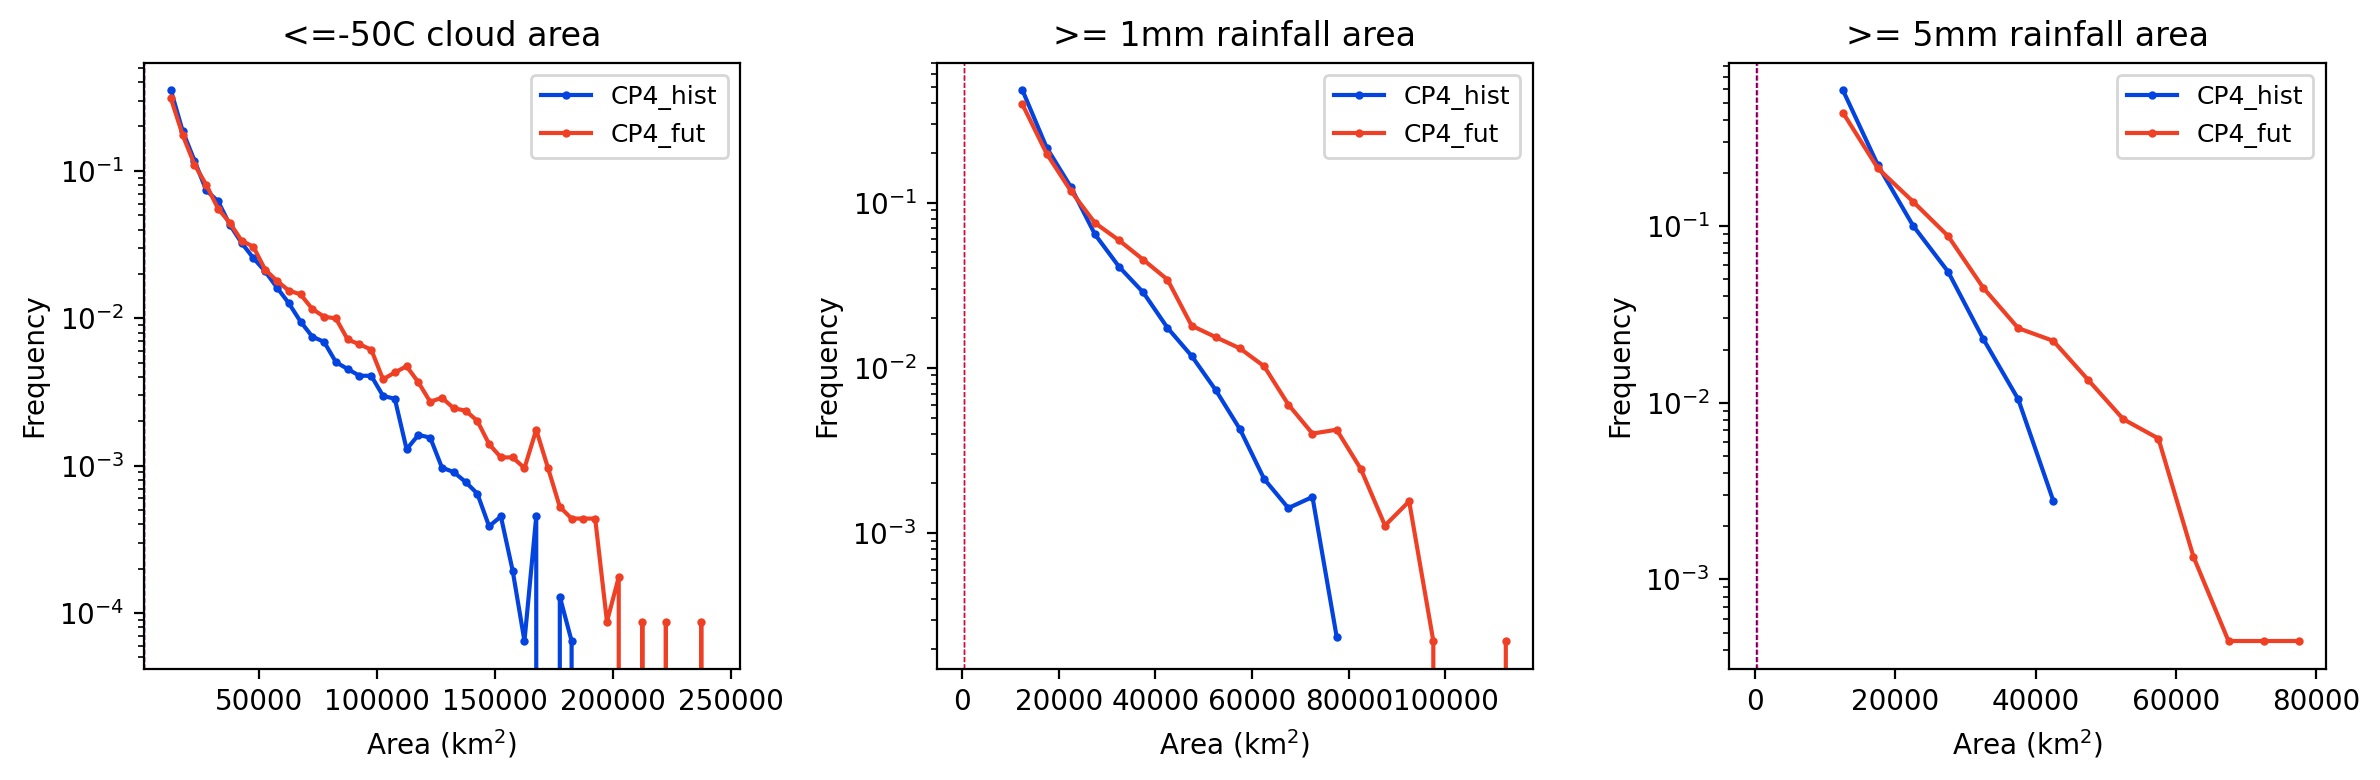

In [205]:
f = plt.figure(figsize=(12,4), dpi=200)
ax = f.add_subplot(131)

var = 'area'
cp4 = hist2d.basic_1d_binning(lahist[var]*4.4**2, np.arange(10000, np.max(lahist[var]*4.4**2),5000))
cp4f = hist2d.basic_1d_binning(lafut[var]*4.4**2, np.arange(10000, np.max(lafut[var]*4.4**2),5000))
plt.plot(cp4['xbins'], cp4['nb']/np.sum(cp4['nb']), color='xkcd:blue', label='CP4_hist', marker='o', markersize=2)
plt.plot(cp4f['xbins'], cp4f['nb']/np.sum(cp4f['nb']), color='xkcd:tomato', label='CP4_fut', marker='o', markersize=2)
plt.ylabel('Frequency')
plt.xlabel(r'Area (km$^{2}$)')
plt.title('<=-50C cloud area')
ax.axvline(np.nanpercentile(lhist[var],75), color='b', linestyle='dashed', linewidth=0.5)
ax.axvline(np.nanpercentile(lfut[var],75), color='r', linestyle='dashed', linewidth=0.5)
plt.legend(fontsize=9)
plt.yscale('log')
plt.tight_layout()

ax = f.add_subplot(132)

var = 'area_1mm'
cp4 = hist2d.basic_1d_binning(lahist[var]*4.4**2, np.arange(10000, np.max(lahist[var]*4.4**2),5000))
cp4f = hist2d.basic_1d_binning(lafut[var]*4.4**2, np.arange(10000, np.max(lafut[var]*4.4**2),5000))
plt.plot(cp4['xbins'], cp4['nb']/np.sum(cp4['nb']), color='xkcd:blue', label='CP4_hist', marker='o', markersize=2)
plt.plot(cp4f['xbins'], cp4f['nb']/np.sum(cp4f['nb']), color='xkcd:tomato', label='CP4_fut', marker='o', markersize=2)
plt.ylabel('Frequency')
plt.xlabel(r'Area (km$^{2}$)')
plt.title('>= 1mm rainfall area')
ax.axvline(np.nanpercentile(lahist[var],75), color='b', linestyle='dashed', linewidth=0.5)
ax.axvline(np.nanpercentile(lafut[var],75), color='r', linestyle='dashed', linewidth=0.5)
plt.legend(fontsize=9)
plt.yscale('log')
plt.tight_layout()

ax = f.add_subplot(133)

var = 'area_5mm'
cp4 = hist2d.basic_1d_binning(lahist[var]*4.4**2, np.arange(10000, np.max(lahist[var]*4.4**2),5000))
cp4f = hist2d.basic_1d_binning(lafut[var]*4.4**2, np.arange(10000, np.max(lafut[var]*4.4**2),5000))
plt.plot(cp4['xbins'], cp4['nb']/np.sum(cp4['nb']), color='xkcd:blue', label='CP4_hist', marker='o', markersize=2)
plt.plot(cp4f['xbins'], cp4f['nb']/np.sum(cp4f['nb']), color='xkcd:tomato', label='CP4_fut', marker='o', markersize=2)
plt.ylabel('Frequency')
plt.xlabel(r'Area (km$^{2}$)')
plt.title('>= 5mm rainfall area')
ax.axvline(np.nanpercentile(lahist[var],75), color='b', linestyle='dashed', linewidth=0.5)
ax.axvline(np.nanpercentile(lafut[var],75), color='r', linestyle='dashed', linewidth=0.5)
plt.legend(fontsize=9)
plt.yscale('log')
plt.tight_layout()
f.savefig('./cp4_cloud_rain_area.jpg')

In [224]:
len(lahist)

28717

In [207]:
len(lahist2)

3645

In [243]:
len(lahist[lahist['lsRain_noon_cl']<=10e-50])

4995

In [129]:
lahist = lahist[(lahist['lsRain_noon_cl']<10e-10)]
lafut = lafut[(lafut['lsRain_noon_cl']<10e-10)]

In [130]:
from shared.utils import u_met
def calc_theta_table(da, moist=False):    
    p = 1000

    t = da['t2_1deg'].values - 273.15
    q = da['q2_1deg'].values
    
    if moist:
        theta = u_met.theta_e(p, t, q)
    else:
        theta = u_met.theta(p,t) 
        
        
    p = 925
    
    t = da['t_srfc_1deg'].values
    q = da['q_srfc_1deg'].values/1000
    
    if moist:
        theta2 = u_met.theta_e(p, t, q)
    else:
        theta2 = u_met.theta(p,t) 
    
    return np.array((theta2+theta)/2)

In [131]:
len(lahist)

7107

In [132]:
len(lahist2)

3645

In [133]:
print(lahist2['area'].min(), lahist2['area'].max())
print(lahist['area'].min(), lahist['area'].max())

517.0 9525.0
258.0 9358.0


In [134]:
print(lahist2['pmax'].min(), lahist2['pmax'].max())
print(lahist['pmax'].min(), lahist['pmax'].max())

0.0765508403821306 81.3293217865276
0.41247964503769063 81.32932194115034


In [135]:
print(lahist2['lat'].min(), lahist2['lat'].max())
print(lahist['lat'].min(), lahist['lat'].max())

9.02850341796875 22.63650131225586
8.016003 22.474499


In [136]:
print(lahist2['lsRain_noon_Smean'].min(), lahist2['lsRain_noon_Smean'].max())
print(lahist['lsRain_noon_cl'].min(), lahist['lsRain_noon_cl'].max())

0.0 0.0
0.0 9.995188189116574e-10


17 [ 4.92734864 65.05320276]
17 lh [-47.26572402  41.44998873]
17 [-10.391356    56.63453955]
17 lh [-31.73828477  55.79956225]
18 [-8.89644275 58.53898797]
18 lh [-32.37148932  56.24804056]
19 [-7.27574851 58.87219354]
19 lh [-30.72044388  58.59182248]


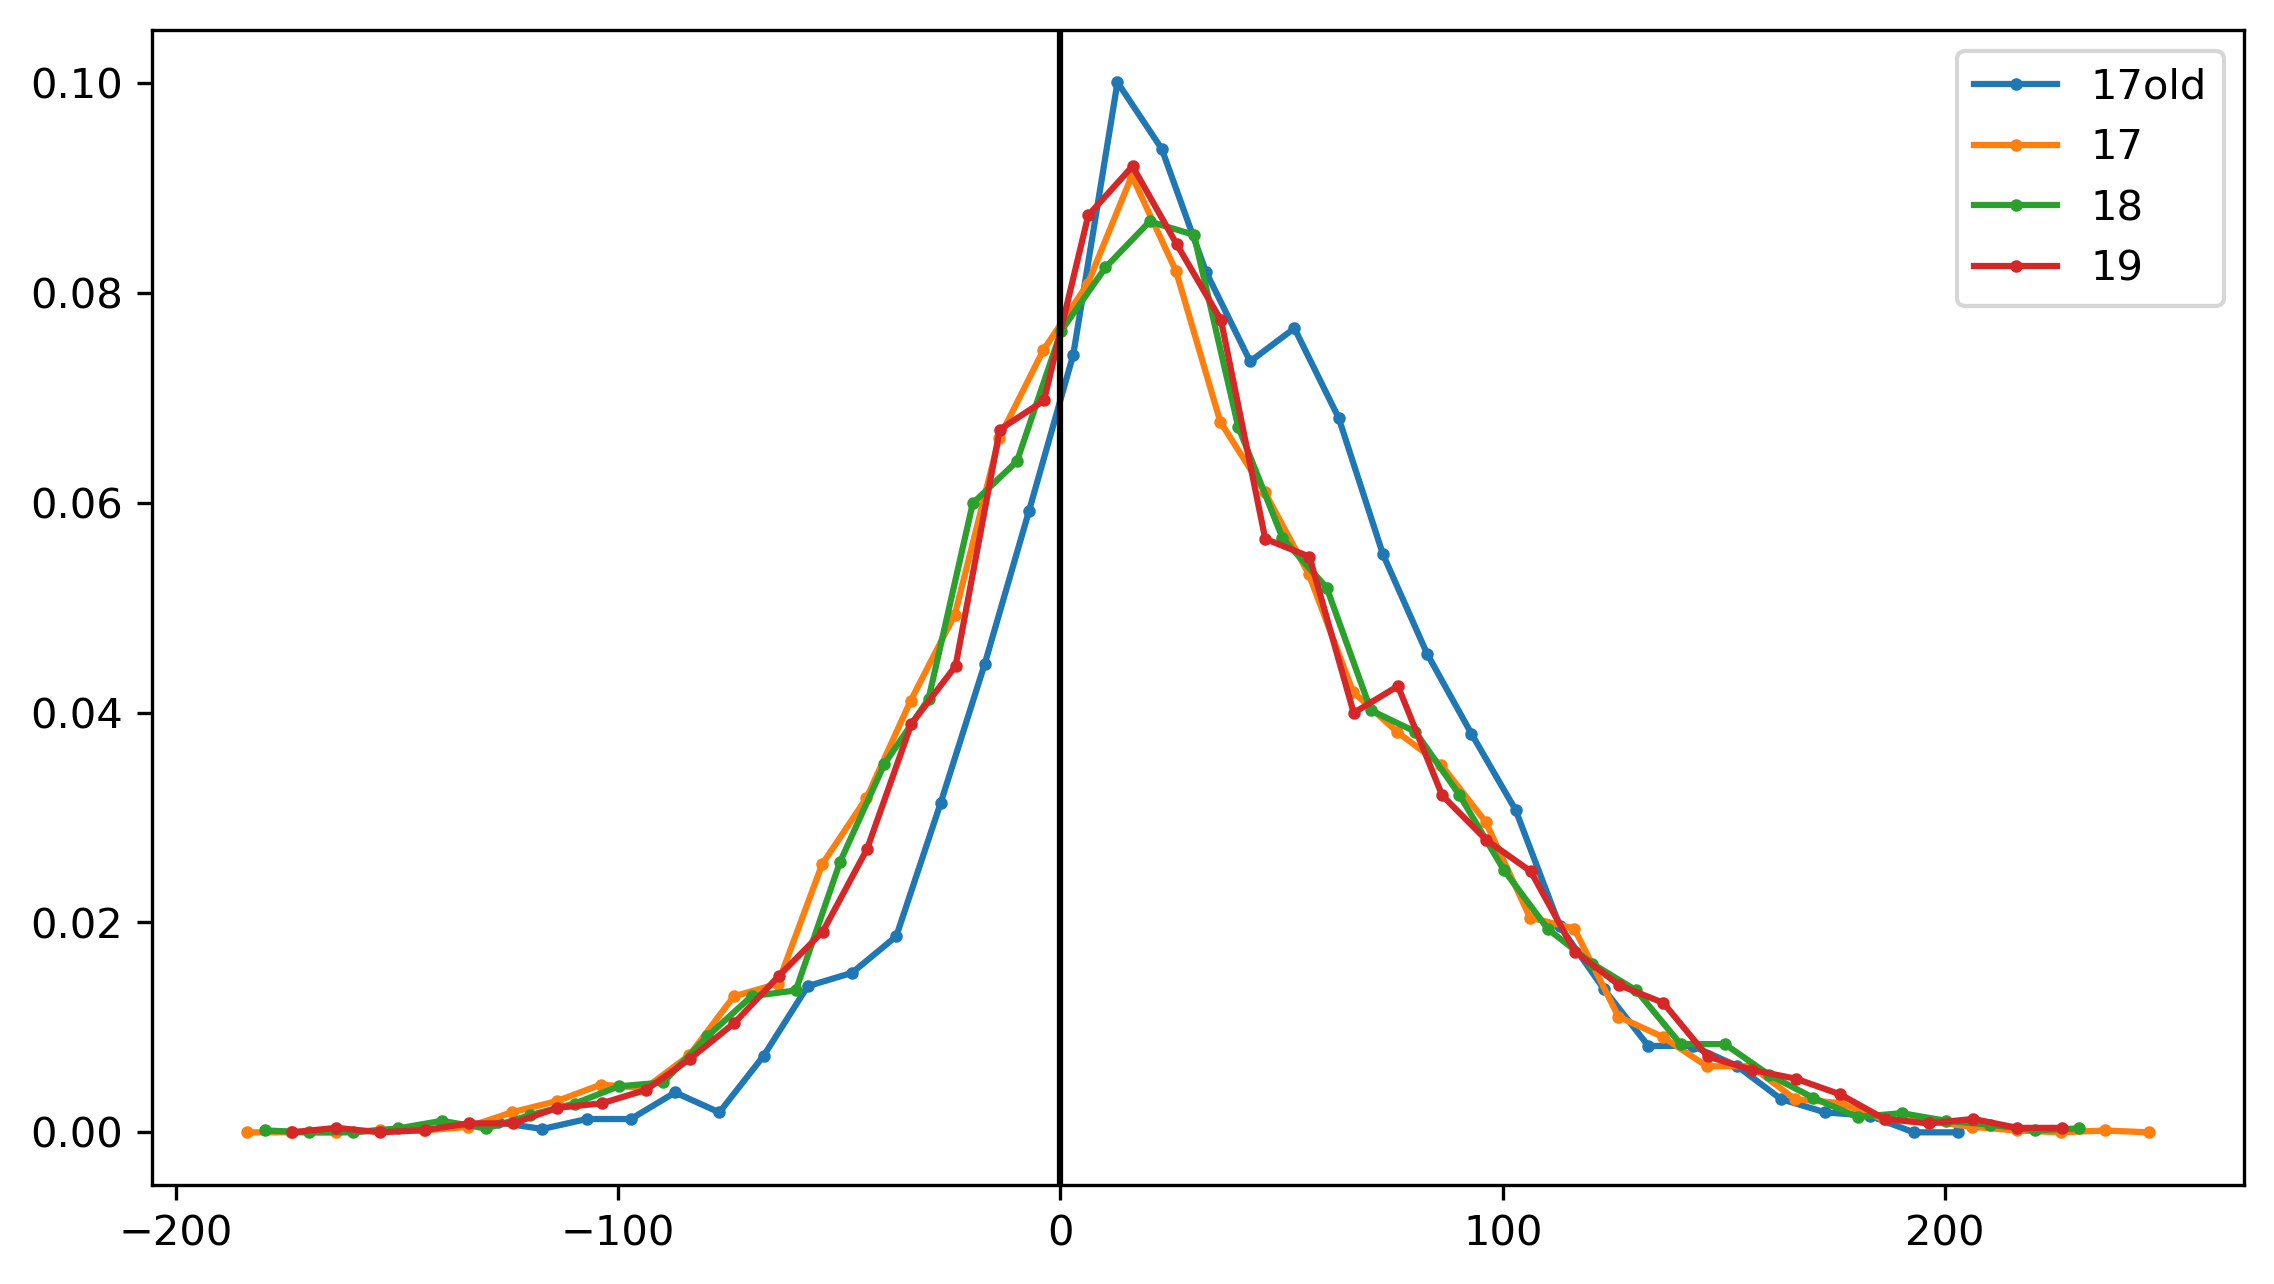

In [244]:
f = plt.figure(figsize=(9,5), dpi=300)
ax = f.add_subplot(111)

for hh in [17]:
    data = lahist2[lahist2['hour']==hh]
    dat = hist2d.basic_1d_binning(data['sh_1deg'], np.arange(np.min(data['sh_1deg']), np.max(data['sh_1deg']),10))
    plt.plot(dat['xbins'], dat['nb']/np.sum(dat['nb']), label=str(hh)+'old', marker='o', markersize=2)
    print(hh, np.nanpercentile(data['sh_1deg'],[25,75]))
    print(hh, 'lh', np.nanpercentile(data['lh_1deg'],[25,75]))

for hh in [17,18,19]:
    data = lahist[(lahist['hour']==hh) & (lhist['lsRain_noon_0.25deg']<=10e-50) ]
    dat = hist2d.basic_1d_binning(data['sh_1deg'], np.arange(np.min(data['sh_1deg']), np.max(data['sh_1deg']),10))
    plt.plot(dat['xbins'], dat['nb']/np.sum(dat['nb']), label=hh, marker='o', markersize=2)
    print(hh, np.nanpercentile(data['sh_1deg'],[25,75]))
    print(hh, 'lh', np.nanpercentile(data['lh_1deg'],[25,75]))
plt.legend()
ax.axvline(0, color='k')

17 [ 4.92734864 65.05320276]
17 lh [-47.26572402  41.44998873]
17 [-4.70434122 67.17492641]
17 lh [-39.89365778  51.70462759]
18 [-3.44560617 64.51184703]
18 lh [-35.78610256  53.48350677]
19 [-1.93383322 67.61840456]
19 lh [-35.82464738  57.2669401 ]


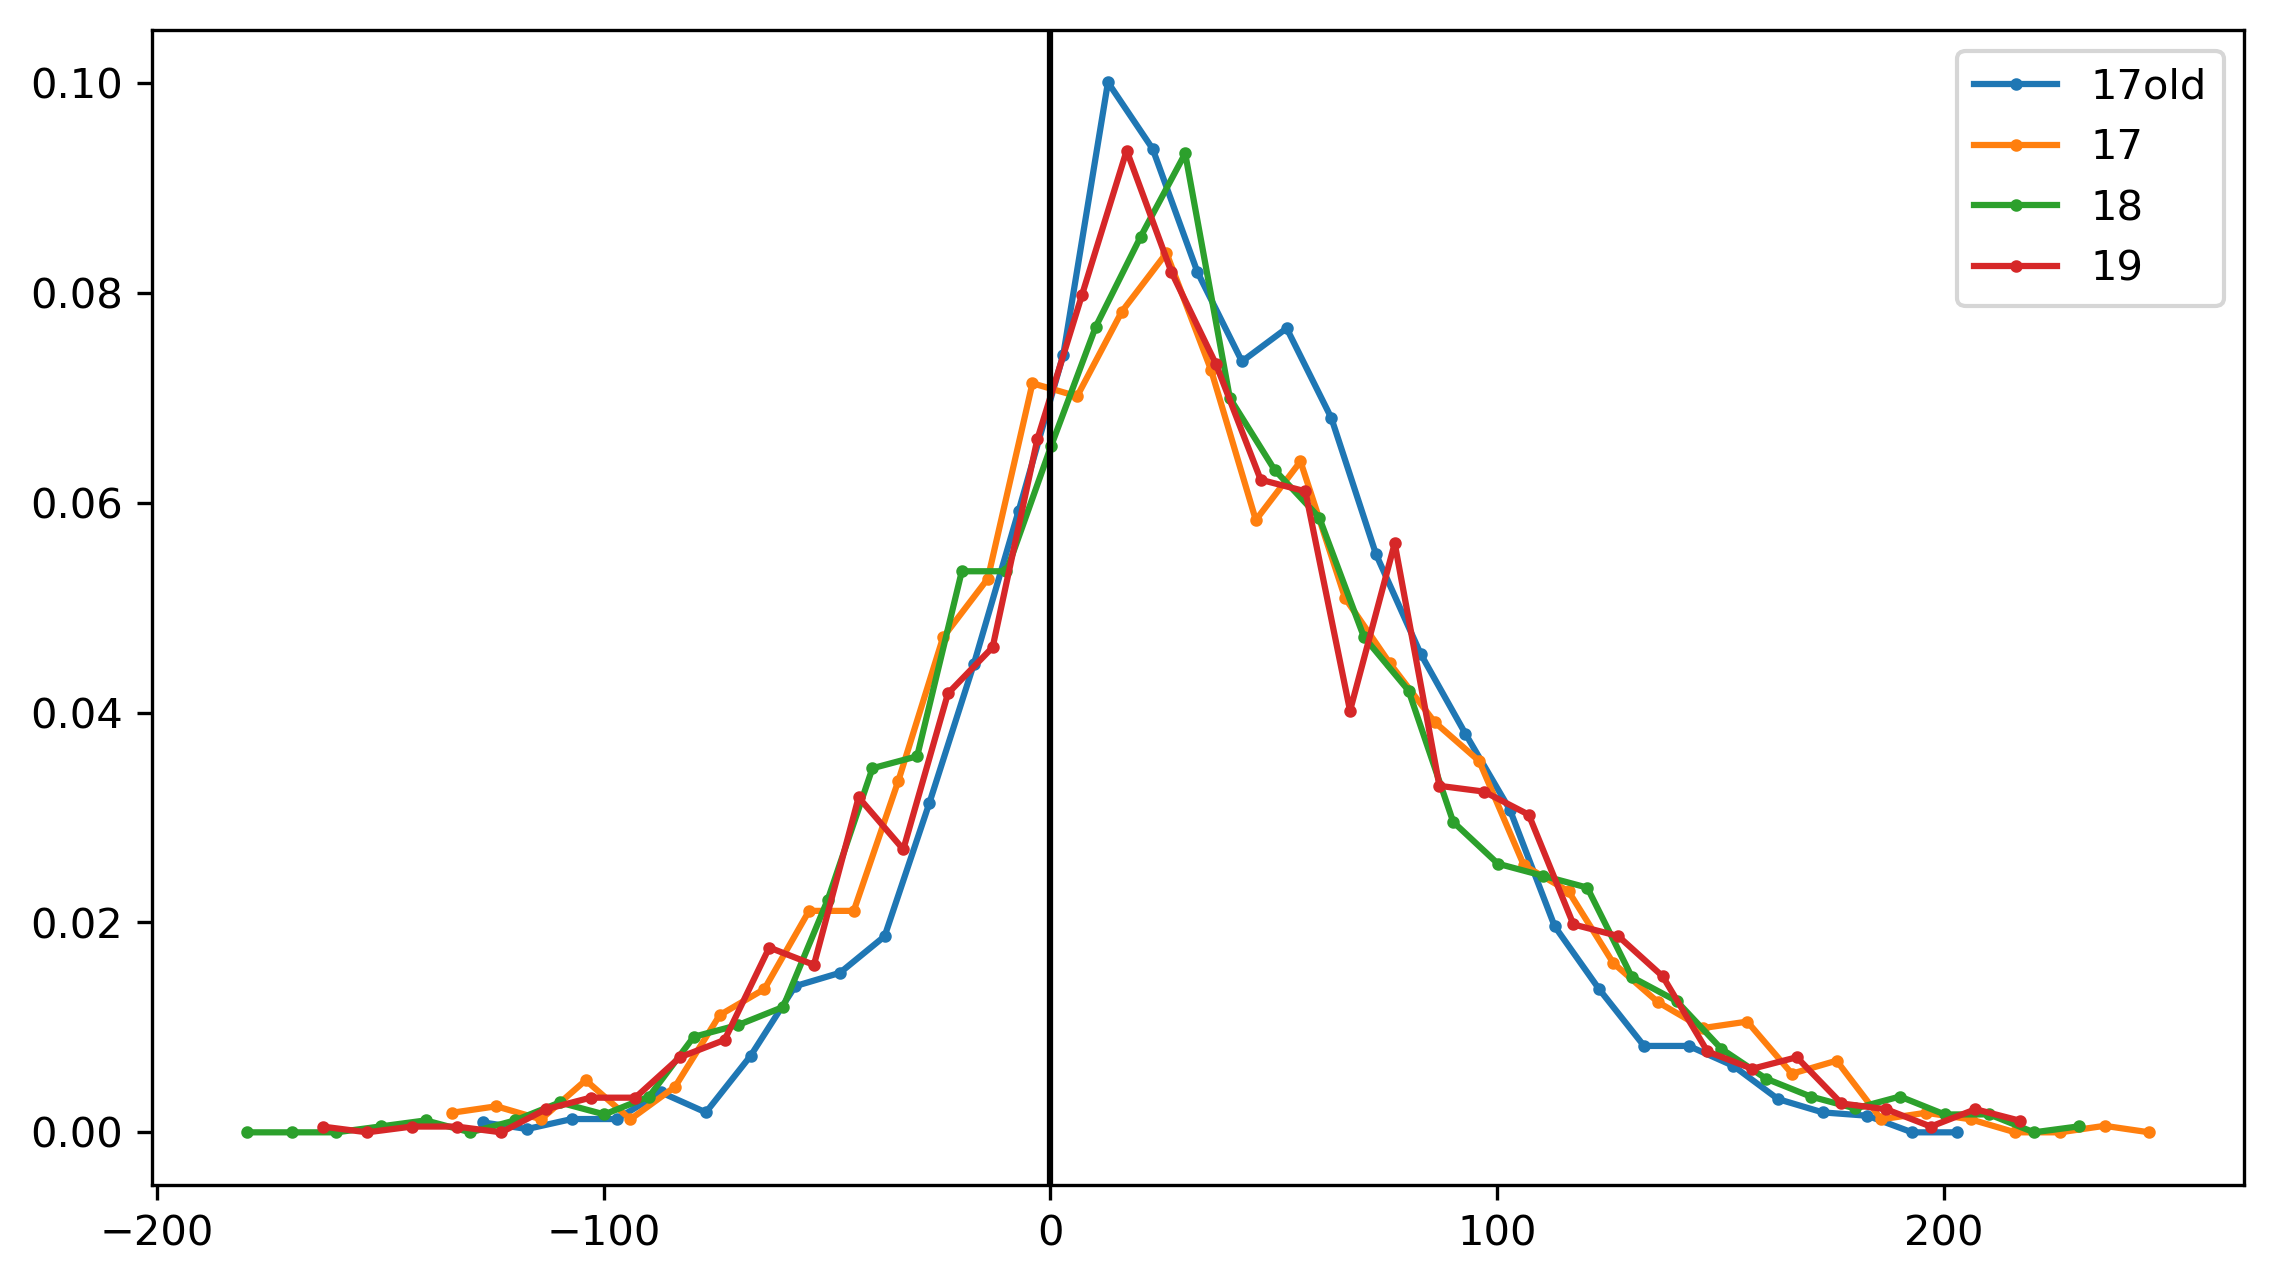

In [39]:
f = plt.figure(figsize=(9,5), dpi=300)
ax = f.add_subplot(111)

for hh in [17]:
    data = lahist2[lahist2['hour']==hh]
    dat = hist2d.basic_1d_binning(data['sh_1deg'], np.arange(np.min(data['sh_1deg']), np.max(data['sh_1deg']),10))
    plt.plot(dat['xbins'], dat['nb']/np.sum(dat['nb']), label=str(hh)+'old', marker='o', markersize=2)
    print(hh, np.nanpercentile(data['sh_1deg'],[25,75]))
    print(hh, 'lh', np.nanpercentile(data['lh_1deg'],[25,75]))

for hh in [17,18,19]:
    data = lahist[(lahist['hour']==hh) & (lahist['area']>=517)  & (lahist['lat']>=9) & (lahist['lsRain_noon_cl']<=10e-5) ]
    dat = hist2d.basic_1d_binning(data['sh_1deg'], np.arange(np.min(data['sh_1deg']), np.max(data['sh_1deg']),10))
    plt.plot(dat['xbins'], dat['nb']/np.sum(dat['nb']), label=hh, marker='o', markersize=2)
    print(hh, np.nanpercentile(data['sh_1deg'],[25,75]))
    print(hh, 'lh', np.nanpercentile(data['lh_1deg'],[25,75]))
plt.legend()
ax.axvline(0, color='k')

In [86]:
lhist['theta-e'] = calc_theta_table(lhist, moist=True)
lhist['theta'] = calc_theta_table(lhist)

lfut['theta-e'] = calc_theta_table(lfut, moist=True)
lfut['theta'] = calc_theta_table(lfut)

In [41]:
lahist['theta-e'] = calc_theta_table(lahist+lhist.mean(), moist=True)
lahist['theta'] = calc_theta_table(lahist+lhist.mean())

lafut['theta-e'] = calc_theta_table(lafut+lfut.mean(), moist=True)
lafut['theta'] = calc_theta_table(lafut+lfut.mean())

lahist['theta-e'] = lahist['theta-e']-lhist['theta-e'].mean()
lafut['theta-e'] = lafut['theta-e']-lfut['theta-e'].mean()

lahist['theta'] = lahist['theta']-lhist['theta'].mean()
lafut['theta'] = lafut['theta']-lfut['theta'].mean()

TypeError: Cannot perform reduction 'mean' with string dtype

<>:18: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:33: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:48: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:68: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:83: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:98: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:18: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences wil

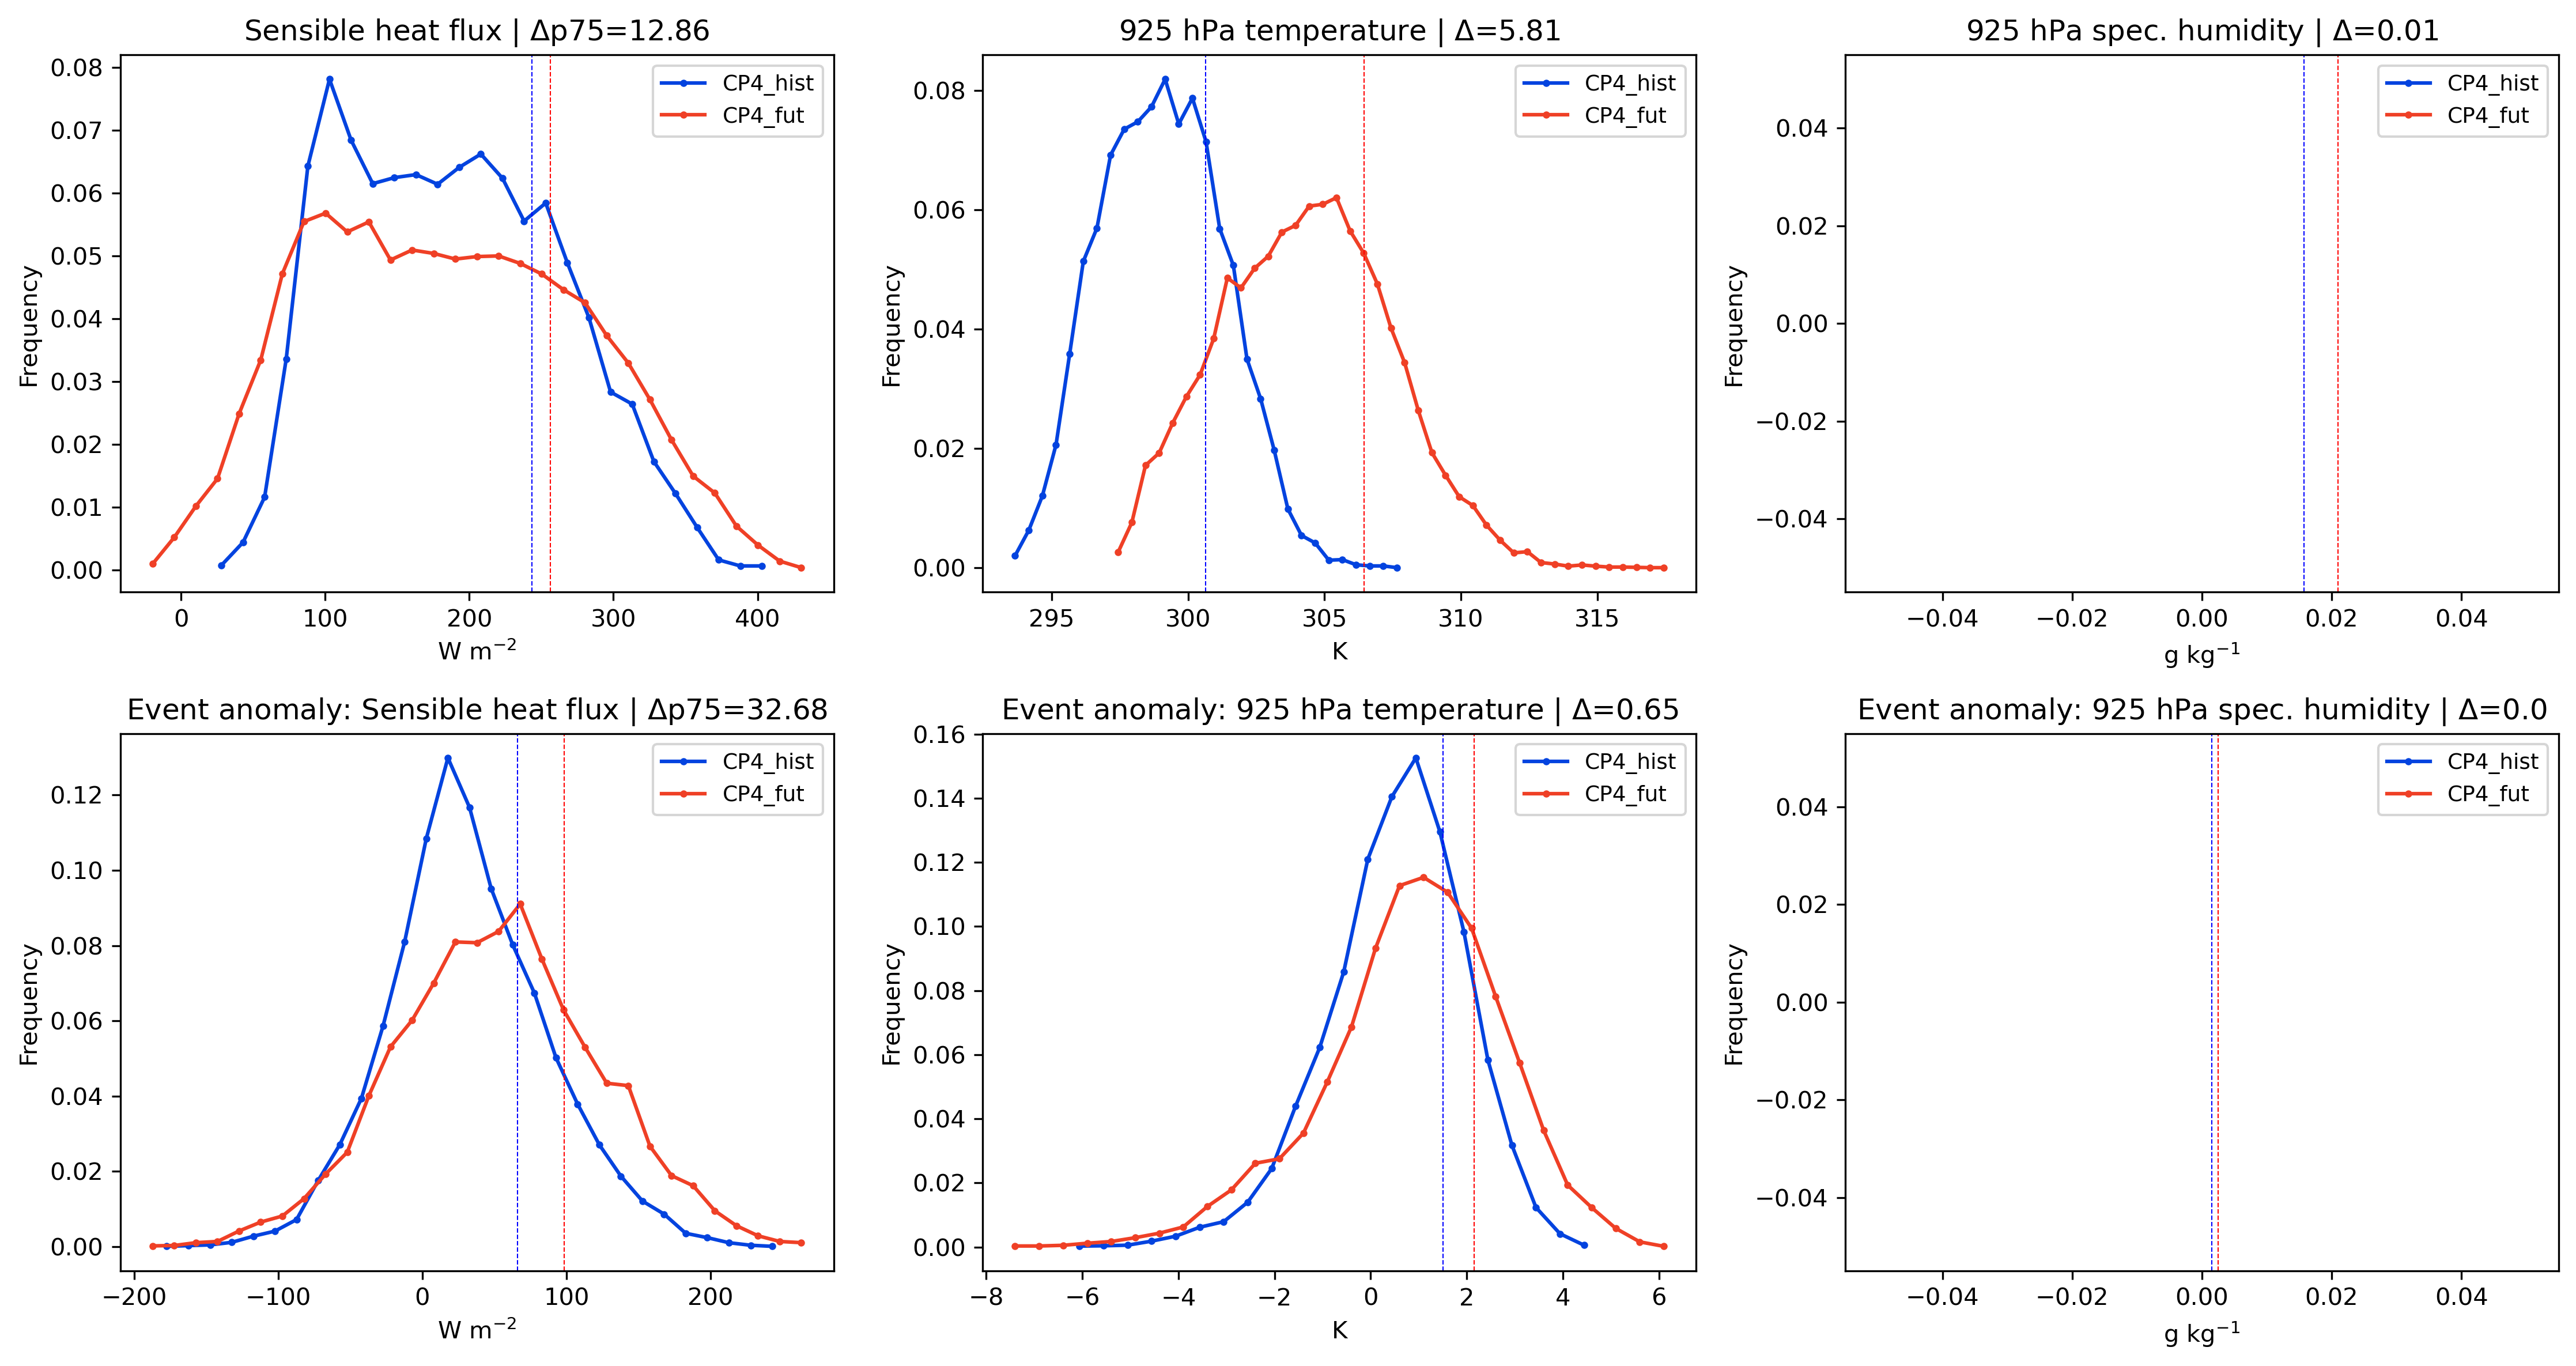

In [42]:
f = plt.figure(figsize=(15,8), dpi=300)



ax = f.add_subplot(231)

var = 'sh_1deg'
efplot = lhist[var]
efhist = efplot
efplot = lfut[var]
effut = efplot
cp4 = hist2d.basic_1d_binning(efhist, np.arange(np.min(efhist), np.max(efhist),15))
cp4f = hist2d.basic_1d_binning(effut, np.arange(np.min(effut), np.max(effut),15))
plt.plot(cp4['xbins'], cp4['nb']/np.sum(cp4['nb']), color='xkcd:blue', label='CP4_hist', marker='o', markersize=2)
plt.plot(cp4f['xbins'], cp4f['nb']/np.sum(cp4f['nb']), color='xkcd:tomato', label='CP4_fut', marker='o', markersize=2)
plt.ylabel('Frequency')
plt.xlabel('W m$^{-2}$')
plt.title('Sensible heat flux | $\Delta$p75='+str(np.round(np.nanpercentile(effut,75)-np.nanpercentile(efhist,75),2)))
ax.axvline(np.nanpercentile(efhist,75), color='b', linestyle='dashed', linewidth=0.5)
ax.axvline(np.nanpercentile(effut,75), color='r', linestyle='dashed', linewidth=0.5)
plt.legend(fontsize=9)


ax = f.add_subplot(232)

var = 't_srfc_1deg'
cp4 = hist2d.basic_1d_binning(lhist[var], np.arange(np.min(lhist[var]), np.max(lhist[var]),0.5))
cp4f = hist2d.basic_1d_binning(lfut[var], np.arange(np.min(lfut[var]), np.max(lfut[var]),0.5))
plt.plot(cp4['xbins'], cp4['nb']/np.sum(cp4['nb']), color='xkcd:blue', label='CP4_hist', marker='o', markersize=2)
plt.plot(cp4f['xbins'], cp4f['nb']/np.sum(cp4f['nb']), color='xkcd:tomato', label='CP4_fut', marker='o', markersize=2)
plt.ylabel('Frequency')
plt.xlabel('K')
plt.title('925 hPa temperature | $\Delta$='+str(np.round(np.nanpercentile(lfut[var],75)-np.nanpercentile(lhist[var],75),2)))
ax.axvline(np.nanpercentile(lhist[var],75), color='b', linestyle='dashed', linewidth=0.5)
ax.axvline(np.nanpercentile(lfut[var],75), color='r', linestyle='dashed', linewidth=0.5)
plt.legend(fontsize=9)


ax = f.add_subplot(233)

var = 'q_srfc_1deg'
cp4 = hist2d.basic_1d_binning(lhist[var], np.arange(np.min(lhist[var]), np.max(lhist[var]),0.5))
cp4f = hist2d.basic_1d_binning(lfut[var], np.arange(np.min(lfut[var]), np.max(lfut[var]),0.5))
plt.plot(cp4['xbins'], cp4['nb']/np.sum(cp4['nb']), color='xkcd:blue', label='CP4_hist', marker='o', markersize=2)
plt.plot(cp4f['xbins'], cp4f['nb']/np.sum(cp4f['nb']), color='xkcd:tomato', label='CP4_fut', marker='o', markersize=2)
plt.ylabel('Frequency')
plt.xlabel('g kg$^{-1}$')
plt.title('925 hPa spec. humidity | $\Delta$='+str(np.round(np.nanpercentile(lfut[var],75)-np.nanpercentile(lhist[var],75),2)))
ax.axvline(np.nanpercentile(lhist[var],75), color='b', linestyle='dashed', linewidth=0.5)
ax.axvline(np.nanpercentile(lfut[var],75), color='r', linestyle='dashed', linewidth=0.5)
plt.legend(fontsize=9)



ax = f.add_subplot(234)

var = 'sh_1deg'
efplot = lahist[var]
efhist = efplot
efplot = lafut[var]
effut = efplot
cp4 = hist2d.basic_1d_binning(efhist, np.arange(np.min(efhist), np.max(efhist),15))
cp4f = hist2d.basic_1d_binning(effut, np.arange(np.min(effut), np.max(effut),15))
plt.plot(cp4['xbins'], cp4['nb']/np.sum(cp4['nb']), color='xkcd:blue', label='CP4_hist', marker='o', markersize=2)
plt.plot(cp4f['xbins'], cp4f['nb']/np.sum(cp4f['nb']), color='xkcd:tomato', label='CP4_fut', marker='o', markersize=2)
plt.ylabel('Frequency')
plt.xlabel('W m$^{-2}$')
plt.title('Event anomaly: Sensible heat flux | $\Delta$p75='+str(np.round(np.nanpercentile(effut,75)-np.nanpercentile(efhist,75),2)))
ax.axvline(np.nanpercentile(efhist,75), color='b', linestyle='dashed', linewidth=0.5)
ax.axvline(np.nanpercentile(effut,75), color='r', linestyle='dashed', linewidth=0.5)
plt.legend(fontsize=9)


ax = f.add_subplot(235)

var = 't_srfc_1deg'
cp4 = hist2d.basic_1d_binning(lahist[var], np.arange(np.min(lahist[var]), np.max(lahist[var]),0.5))
cp4f = hist2d.basic_1d_binning(lafut[var], np.arange(np.min(lafut[var]), np.max(lafut[var]),0.5))
plt.plot(cp4['xbins'], cp4['nb']/np.sum(cp4['nb']), color='xkcd:blue', label='CP4_hist', marker='o', markersize=2)
plt.plot(cp4f['xbins'], cp4f['nb']/np.sum(cp4f['nb']), color='xkcd:tomato', label='CP4_fut', marker='o', markersize=2)
plt.ylabel('Frequency')
plt.xlabel('K')
plt.title('Event anomaly: 925 hPa temperature | $\Delta$='+str(np.round(np.nanpercentile(lafut[var],75)-np.nanpercentile(lahist[var],75),2)))
ax.axvline(np.nanpercentile(lahist[var],75), color='b', linestyle='dashed', linewidth=0.5)
ax.axvline(np.nanpercentile(lafut[var],75), color='r', linestyle='dashed', linewidth=0.5)
plt.legend(fontsize=9)


ax = f.add_subplot(236)

var = 'q_mid_1deg'
cp4 = hist2d.basic_1d_binning(lahist[var], np.arange(np.min(lahist[var]), np.max(lahist[var]),0.5))
cp4f = hist2d.basic_1d_binning(lafut[var], np.arange(np.min(lafut[var]), np.max(lafut[var]),0.5))
plt.plot(cp4['xbins'], cp4['nb']/np.sum(cp4['nb']), color='xkcd:blue', label='CP4_hist', marker='o', markersize=2)
plt.plot(cp4f['xbins'], cp4f['nb']/np.sum(cp4f['nb']), color='xkcd:tomato', label='CP4_fut', marker='o', markersize=2)
plt.ylabel('Frequency')
plt.xlabel('g kg$^{-1}$')
plt.title('Event anomaly: 925 hPa spec. humidity | $\Delta$='+str(np.round(np.nanpercentile(lafut[var],75)-np.nanpercentile(lahist[var],75),2)))
ax.axvline(np.nanpercentile(lahist[var],75), color='b', linestyle='dashed', linewidth=0.5)
ax.axvline(np.nanpercentile(lafut[var],75), color='r', linestyle='dashed', linewidth=0.5)
plt.legend(fontsize=9)
plt.tight_layout()
#f.savefig(cnst.network_data + 'figs/LMCS/CP4_PNASstudy/raw_variable_distributions_100km-Box.jpg')

<>:18: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:37: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:52: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:72: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:91: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:106: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:18: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences wi

KeyError: 'theta'

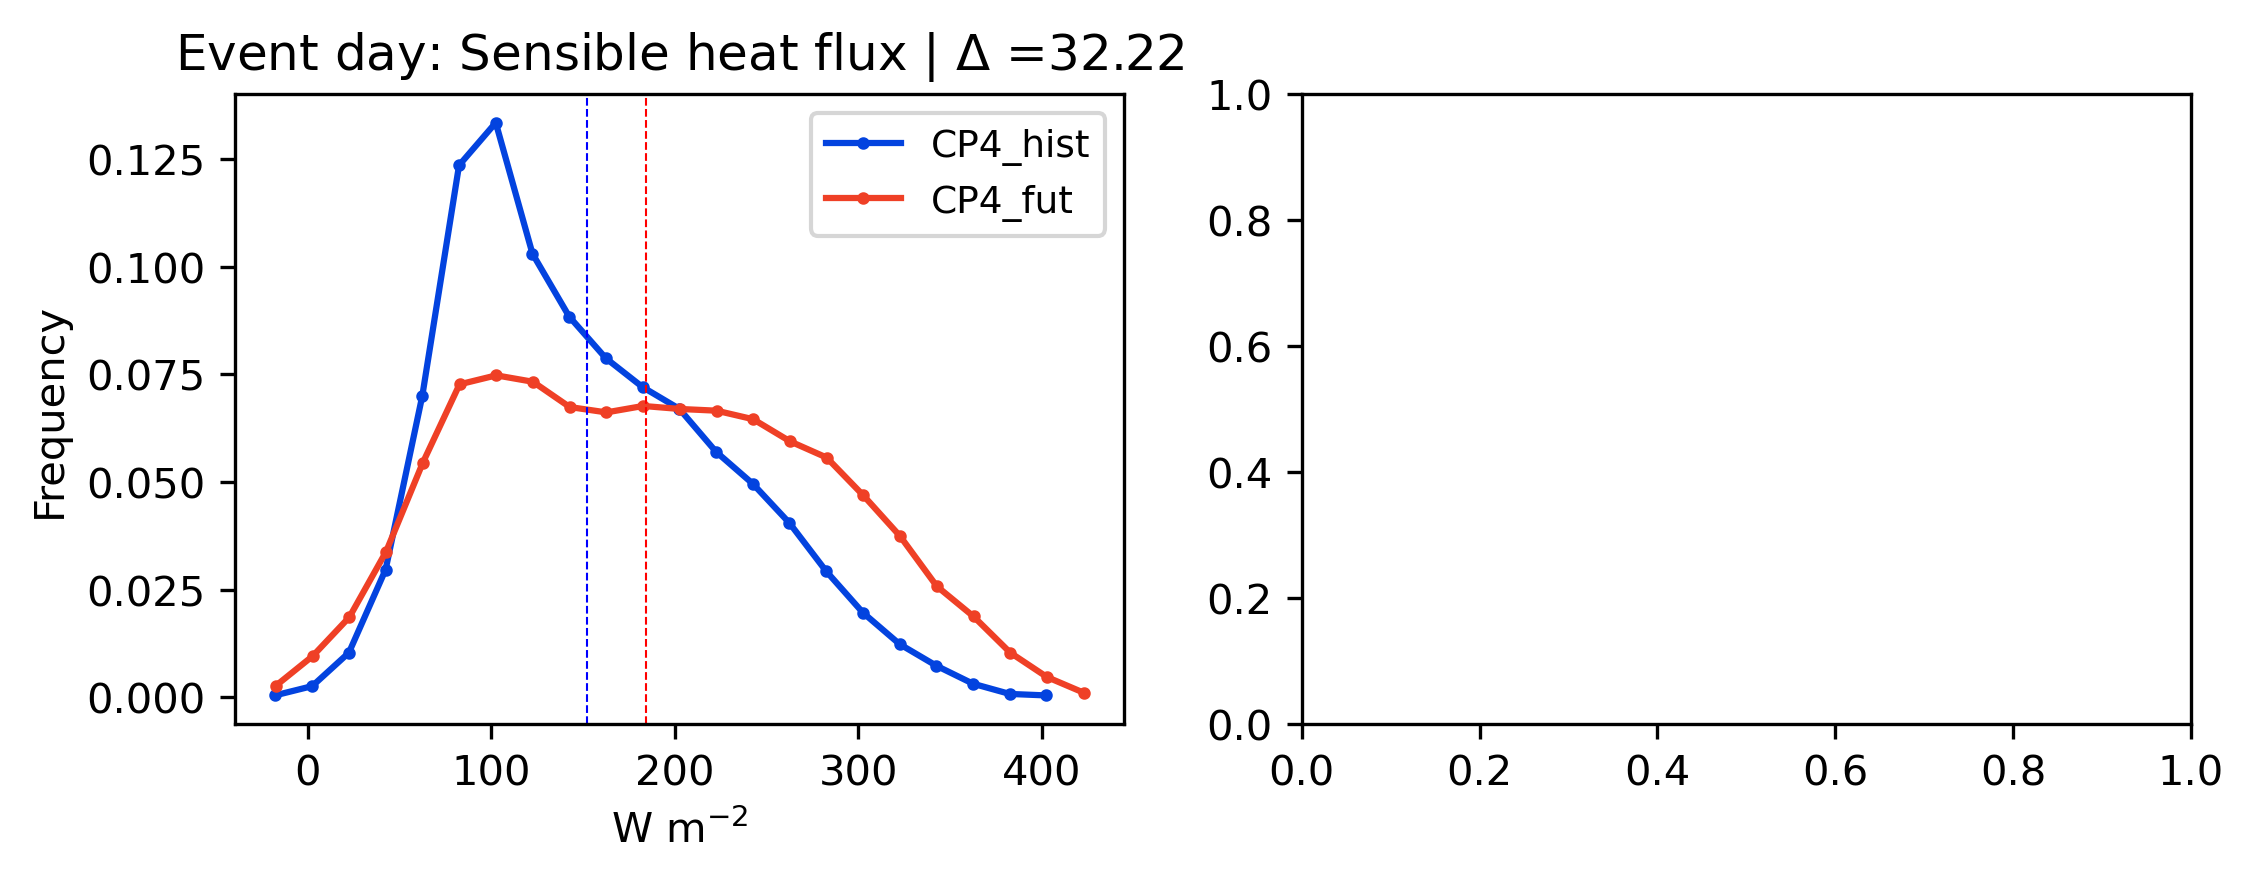

In [209]:
f = plt.figure(figsize=(13,6), dpi=300)



ax = f.add_subplot(231)

var = 'sh_1deg'
efplot = lhist[var]
efhist = efplot
efplot = lfut[var]
effut = efplot
cp4 = hist2d.basic_1d_binning(efhist, np.arange(np.min(efhist), np.max(efhist),20))
cp4f = hist2d.basic_1d_binning(effut, np.arange(np.min(effut), np.max(effut),20))
plt.plot(cp4['xbins'], cp4['nb']/np.sum(cp4['nb']), color='xkcd:blue', label='CP4_hist', marker='o', markersize=2)
plt.plot(cp4f['xbins'], cp4f['nb']/np.sum(cp4f['nb']), color='xkcd:tomato', label='CP4_fut', marker='o', markersize=2)
plt.ylabel('Frequency')
plt.xlabel('W m$^{-2}$')
plt.title('Event day: Sensible heat flux | $\Delta$ ='+str(np.round(np.nanmean(effut)-np.nanmean(efhist),2)))
ax.axvline(np.nanmean(efhist), color='b', linestyle='dashed', linewidth=0.5)
ax.axvline(np.nanmean(effut), color='r', linestyle='dashed', linewidth=0.5)
plt.legend(fontsize=9)


ax = f.add_subplot(232)

var = 'theta'

thet_hist = lhist[var]
thet_fut = lfut[var]

cp4 = hist2d.basic_1d_binning(thet_hist, np.arange(np.min(thet_hist), np.max(thet_hist),0.5))
cp4f = hist2d.basic_1d_binning(thet_fut, np.arange(np.min(thet_fut), np.max(thet_fut),0.5))
plt.plot(cp4['xbins'], cp4['nb']/np.sum(cp4['nb']), color='xkcd:blue', label='CP4_hist', marker='o', markersize=2)
plt.plot(cp4f['xbins'], cp4f['nb']/np.sum(cp4f['nb']), color='xkcd:tomato', label='CP4_fut', marker='o', markersize=2)
plt.ylabel('Frequency')
plt.xlabel('K')
plt.title('Event day: theta-e from T925 | $\Delta$ ='+str(np.round(np.nanmean(lfut[var])-np.nanmean(lhist[var]),2)))
ax.axvline(np.nanmean(lhist[var]), color='b', linestyle='dashed', linewidth=0.5)
ax.axvline(np.nanmean(lfut[var]), color='r', linestyle='dashed', linewidth=0.5)
plt.legend(fontsize=9)


ax = f.add_subplot(233)

var = 'theta-e'
cp4 = hist2d.basic_1d_binning(lhist[var]-thet_hist, np.arange(np.min(lhist[var]-thet_hist), np.max(lhist[var]-thet_hist),1))
cp4f = hist2d.basic_1d_binning(lfut[var]-thet_fut, np.arange(np.min(lfut[var]-thet_fut), np.max(lfut[var]-thet_fut),1))
plt.plot(cp4['xbins'], cp4['nb']/np.sum(cp4['nb']), color='xkcd:blue', label='CP4_hist', marker='o', markersize=2)
plt.plot(cp4f['xbins'], cp4f['nb']/np.sum(cp4f['nb']), color='xkcd:tomato', label='CP4_fut', marker='o', markersize=2)
plt.ylabel('Frequency')
plt.xlabel('K')
plt.title('Event day: theta-e from q925 | $\Delta$ ='+str(np.round(np.nanmean(lfut[var]-thet_fut)-np.nanmean(lhist[var]-thet_hist),2)))
ax.axvline(np.nanmean(lhist[var]-thet_hist), color='b', linestyle='dashed', linewidth=0.5)
ax.axvline(np.nanmean(lfut[var]-thet_fut), color='r', linestyle='dashed', linewidth=0.5)
plt.legend(fontsize=9)



ax = f.add_subplot(234)

var = 'sh_1deg'
efplot = lahist[var]
efhist = efplot
efplot = lafut[var]
effut = efplot
cp4 = hist2d.basic_1d_binning(efhist, np.arange(np.min(efhist), np.max(efhist),20))
cp4f = hist2d.basic_1d_binning(effut, np.arange(np.min(effut), np.max(effut),20))
plt.plot(cp4['xbins'], cp4['nb']/np.sum(cp4['nb']), color='xkcd:blue', label='CP4_hist', marker='o', markersize=2)
plt.plot(cp4f['xbins'], cp4f['nb']/np.sum(cp4f['nb']), color='xkcd:tomato', label='CP4_fut', marker='o', markersize=2)
plt.ylabel('Frequency')
plt.xlabel('W m$^{-2}$')
plt.title('Anomaly: sensible heat flux | $\Delta$ ='+str(np.round(np.nanmean(effut)-np.nanmean(efhist),2))) 
ax.axvline(np.nanmean(efhist), color='b', linestyle='dashed', linewidth=0.5)
ax.axvline(np.nanmean(effut), color='r', linestyle='dashed', linewidth=0.5)
plt.legend(fontsize=9)


ax = f.add_subplot(235)

var = 'theta'

thet_hist = lahist[var]
thet_fut = lafut[var]

cp4 = hist2d.basic_1d_binning(thet_hist, np.arange(np.min(thet_hist), np.max(thet_hist),0.5))
cp4f = hist2d.basic_1d_binning(thet_fut, np.arange(np.min(thet_fut), np.max(thet_fut),0.5))
plt.plot(cp4['xbins'], cp4['nb']/np.sum(cp4['nb']), color='xkcd:blue', label='CP4_hist', marker='o', markersize=2)
plt.plot(cp4f['xbins'], cp4f['nb']/np.sum(cp4f['nb']), color='xkcd:tomato', label='CP4_fut', marker='o', markersize=2)
plt.ylabel('Frequency')
plt.xlabel('K')
plt.title('Anomaly: theta-e from T925 | $\Delta$ ='+str(np.round(np.nanmean(lafut[var])-np.nanmean(lahist[var]),2))) 
ax.axvline(np.nanmean(lahist[var]), color='b', linestyle='dashed', linewidth=0.5)
ax.axvline(np.nanmean(lafut[var]), color='r', linestyle='dashed', linewidth=0.5)
plt.legend(fontsize=9)


ax = f.add_subplot(236)

var = 'theta-e'
cp4 = hist2d.basic_1d_binning(lahist[var]-thet_hist, np.arange(np.min(lahist[var]-thet_hist), np.max(lahist[var]-thet_hist),1))
cp4f = hist2d.basic_1d_binning(lafut[var]-thet_fut, np.arange(np.min(lafut[var]-thet_fut), np.max(lafut[var]-thet_fut),1))
plt.plot(cp4['xbins'], cp4['nb']/np.sum(cp4['nb']), color='xkcd:blue', label='CP4_hist', marker='o', markersize=2)
plt.plot(cp4f['xbins'], cp4f['nb']/np.sum(cp4f['nb']), color='xkcd:tomato', label='CP4_fut', marker='o', markersize=2)
plt.ylabel('Frequency')
plt.xlabel('K')
plt.title('Anomaly: theta-e from q925 | $\Delta$ ='+str(np.round(np.nanmean(lafut[var]-thet_fut)-np.nanmean(lahist[var]-thet_hist),3)))
ax.axvline(np.nanmean(lahist[var]-thet_hist), color='b', linestyle='dashed', linewidth=0.5)
ax.axvline(np.nanmean(lafut[var]-thet_fut), color='r', linestyle='dashed', linewidth=0.5)
plt.legend(fontsize=9)
plt.tight_layout()
#f.savefig(cnst.network_data + 'figs/LMCS/CP4_PNASstudy/theta_variable_distributions_100km-Box.jpg')

In [44]:
print(list(lhist.keys()))

['tcwv_0.25deg', 'sh_0.25deg', 'lh_0.25deg', 't2_0.25deg', 'q2_0.25deg', 'pblH_0.25deg', 'shear_0.25deg', 'u_mid_0.25deg', 'u_srfc_0.25deg', 'v_mid_0.25deg', 'v_srfc_0.25deg', 'q_mid_0.25deg', 't_mid_0.25deg', 't_srfc_0.25deg', 'q_srfc_0.25deg', 'geoH_srfc_0.25deg', 'lsRain_noon_0.25deg', 'lwout_noon_0.25deg', 'SM_0.25deg', 'lw_net_0.25deg', 'sw_in_0.25deg', 'sw_net_0.25deg', 'u10_0.25deg', 'v10_0.25deg', 'tcwv_1deg', 'sh_1deg', 'lh_1deg', 't2_1deg', 'q2_1deg', 'pblH_1deg', 'shear_1deg', 'u_mid_1deg', 'u_srfc_1deg', 'v_mid_1deg', 'v_srfc_1deg', 'q_mid_1deg', 't_mid_1deg', 't_srfc_1deg', 'q_srfc_1deg', 'geoH_srfc_1deg', 'lsRain_noon_1deg', 'lwout_noon_1deg', 'SM_1deg', 'lw_net_1deg', 'sw_in_1deg', 'sw_net_1deg', 'u10_1deg', 'v10_1deg', 'tcwv_2deg', 'sh_2deg', 'lh_2deg', 't2_2deg', 'q2_2deg', 'pblH_2deg', 'shear_2deg', 'u_mid_2deg', 'u_srfc_2deg', 'v_mid_2deg', 'v_srfc_2deg', 'q_mid_2deg', 't_mid_2deg', 't_srfc_2deg', 'q_srfc_2deg', 'geoH_srfc_2deg', 'lsRain_noon_2deg', 'lwout_noon_2deg'

In [210]:
histp25, histp75 = np.nanpercentile(lahist['SM_1deg'], [25,75])
futp25, futp75 = np.nanpercentile(lafut['SM_1deg'], [25,75])

histposlow = lahist['SM_1deg'] > histp75
histposhigh = lahist['SM_1deg'] < histp25

futposlow = lafut['SM_1deg'] > futp75
futposhigh = lafut['SM_1deg'] < futp25

In [211]:
print(histp25, histp75)

-3.7993587979542136 1.3291564013841624


In [212]:
print(np.nanpercentile(lahist2['sh_1deg'], [25,75]))

[ 4.92734864 65.05320276]


In [213]:
print(futp25, futp75)

-5.329258435162372 0.0006845699989283204


In [214]:
lahist.shape

(28717, 134)

In [215]:
lafut.shape

(19899, 130)

In [216]:
lhist['pmax'].min()

0.41247964503769063

In [217]:
lafut['SM_1deg'].min()

-16.480714981730475

In [218]:
print(list(lahist.keys()))

['tcwv_0.25deg', 'sh_0.25deg', 'lh_0.25deg', 't2_0.25deg', 'q2_0.25deg', 'pblH_0.25deg', 'shear_0.25deg', 'u_mid_0.25deg', 'u_srfc_0.25deg', 'v_mid_0.25deg', 'v_srfc_0.25deg', 'q_mid_0.25deg', 't_mid_0.25deg', 't_srfc_0.25deg', 'q_srfc_0.25deg', 'geoH_srfc_0.25deg', 'lsRain_noon_0.25deg', 'lwout_noon_0.25deg', 'SM_0.25deg', 'lw_net_0.25deg', 'sw_in_0.25deg', 'sw_net_0.25deg', 'u10_0.25deg', 'v10_0.25deg', 'tcwv_1deg', 'sh_1deg', 'lh_1deg', 't2_1deg', 'q2_1deg', 'pblH_1deg', 'shear_1deg', 'u_mid_1deg', 'u_srfc_1deg', 'v_mid_1deg', 'v_srfc_1deg', 'q_mid_1deg', 't_mid_1deg', 't_srfc_1deg', 'q_srfc_1deg', 'geoH_srfc_1deg', 'lsRain_noon_1deg', 'lwout_noon_1deg', 'SM_1deg', 'lw_net_1deg', 'sw_in_1deg', 'sw_net_1deg', 'u10_1deg', 'v10_1deg', 'tcwv_2deg', 'sh_2deg', 'lh_2deg', 't2_2deg', 'q2_2deg', 'pblH_2deg', 'shear_2deg', 'u_mid_2deg', 'u_srfc_2deg', 'v_mid_2deg', 'v_srfc_2deg', 'q_mid_2deg', 't_mid_2deg', 't_srfc_2deg', 'q_srfc_2deg', 'geoH_srfc_2deg', 'lsRain_noon_2deg', 'lwout_noon_2deg'

<>:340: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:342: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:340: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:342: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
/tmp/ipykernel_332/3629635006.py:340: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  plt.ylabel('$\Delta$Frequency')
/tmp/ipykernel_332/3629635006.py:342: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw st

t2 wet 18880026.0 1.2811845507562086e-08
t2 dry 11373620.0 1.7769656361026995e-251
t2 wet 17811041.0 0.956233782654061
t2 dry 11303595.0 6.12101784410417e-257
t2 wet 11131108.0 1.198225519409244e-270
t2 dry 9326832.0 0.0
allcase difference 14.260934274445976
drycase difference 16.63176055025703
allcase difference rel to hist 0.6151990415226769
drycase difference rel to hist 0.6725484942071497
t2 wet 11131108.0 1.198225519409244e-270
t2 dry 9326832.0 0.0
SUMTEST -6.217248937900877e-15
allcase difference 14.260934274445976
drycase difference 16.63176055025703
allcase difference rel to hist 0.6151990415226769
drycase difference rel to hist 0.6725484942071497


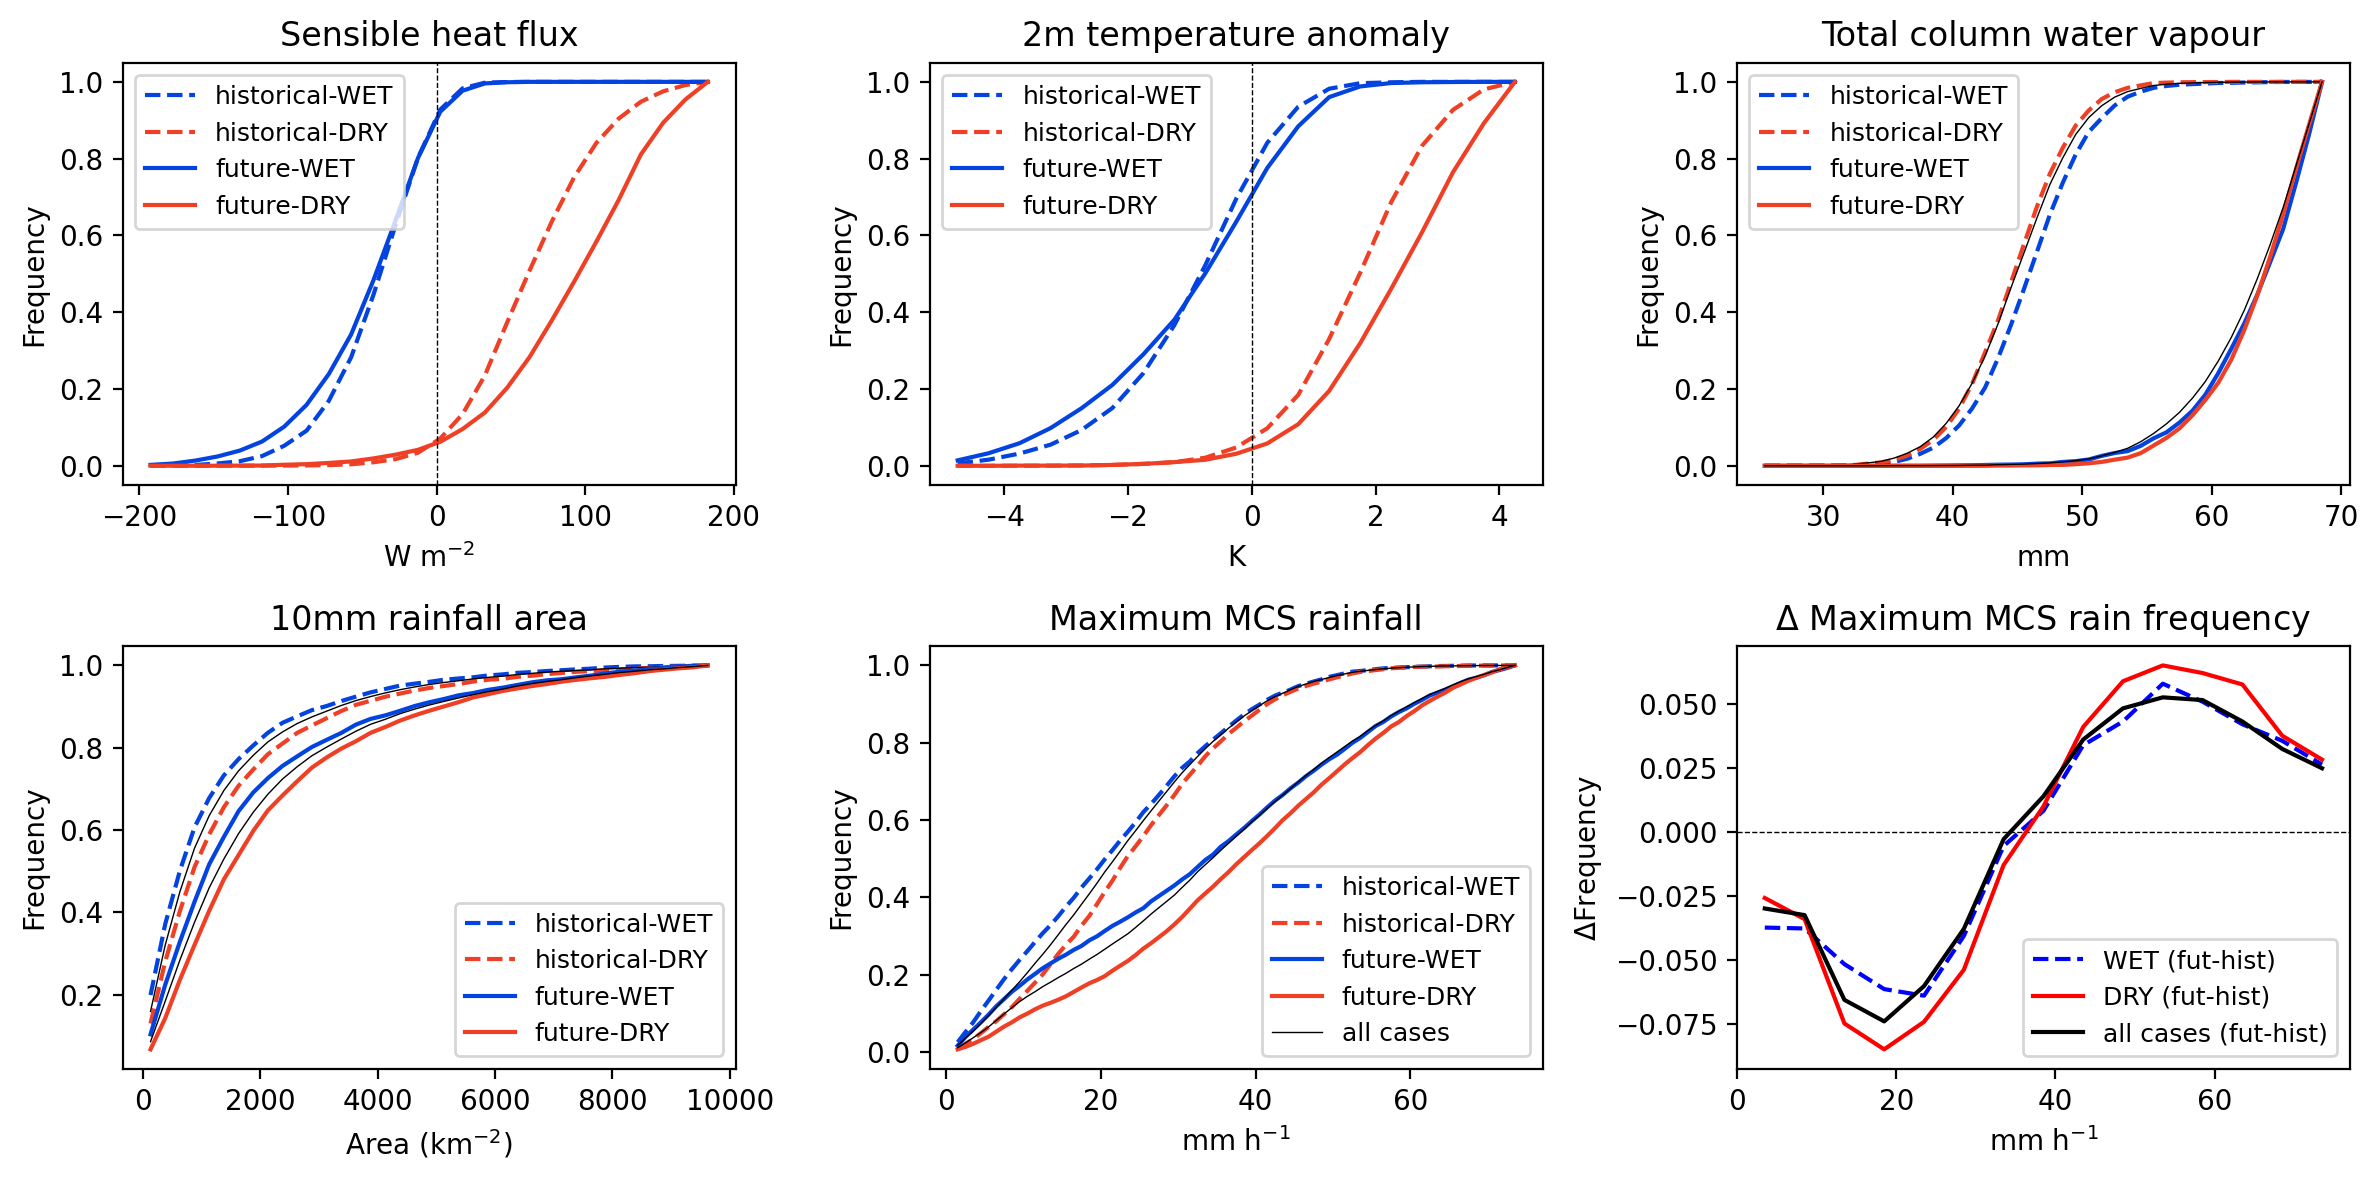

In [219]:
f = plt.figure(figsize=(12,6), dpi=200)
ax1 = f.add_subplot(231)

var = 'sh_1deg'
low = lahist[var][histposlow]
high = lahist[var][histposhigh]
alls = lahist[var]

flow = lafut[var][futposlow]
fhigh = lafut[var][futposhigh]
falls = lafut[var]

nparange = np.arange(-200, 200,15) # np.arange(-15,15,1)#

cp4 = hist2d.basic_1d_binning(low,  nparange)
cp4f = hist2d.basic_1d_binning(high, nparange)
alle = hist2d.basic_1d_binning(alls, nparange)

fcp4 = hist2d.basic_1d_binning(flow, nparange)
fcp4f = hist2d.basic_1d_binning(fhigh, nparange)
falle = hist2d.basic_1d_binning(falls, nparange)



bins=cp4['xbins']

cumlow = np.cumsum(cp4['nb']/np.sum(cp4['nb']))
cumhigh = np.cumsum(cp4f['nb']/np.sum(cp4f['nb']))
cumall = np.cumsum(alle['nb']/np.sum(alle['nb']))

fcumlow = np.cumsum(fcp4['nb']/np.sum(fcp4['nb']))
fcumhigh = np.cumsum(fcp4f['nb']/np.sum(fcp4f['nb']))
fcumall = np.cumsum(falle['nb']/np.sum(falle['nb']))

stat, pval = stats.mannwhitneyu(low, flow, nan_policy='omit')
print('t2 wet', stat,pval)
stat, pval = stats.mannwhitneyu(high, fhigh, nan_policy='omit')
print('t2 dry', stat,pval)

plt.plot(bins, cumlow, color='xkcd:blue', label='historical-WET', linestyle='dashed')
plt.plot(bins, cumhigh, color='xkcd:tomato', label='historical-DRY', linestyle='dashed')
#plt.plot(bins, cumall, color='k', label='future' )

plt.plot(bins, fcumlow, color='xkcd:blue', label='future-WET' )
plt.plot(bins, fcumhigh, color='xkcd:tomato', label='future-DRY' )
ax1.axvline(0, color='k', linestyle='dashed', linewidth=0.5)
#plt.plot(bins, fcumall, color='grey', label='future' )


plt.ylabel('Frequency')
plt.xlabel('W m$^{-2}$')
plt.title('Sensible heat flux')
plt.legend(fontsize=9)
plt.legend(fontsize=9)


ax1 = f.add_subplot(232)

var = 't2_1deg'
low = lahist[var][histposlow]
high = lahist[var][histposhigh]
alls = lahist[var]

flow = lafut[var][futposlow]
fhigh = lafut[var][futposhigh]
falls = lafut[var]


cp4 = hist2d.basic_1d_binning(low, np.arange(-5, 5,0.5))
cp4f = hist2d.basic_1d_binning(high, np.arange(-5, 5,0.5))
alle = hist2d.basic_1d_binning(alls, np.arange(-5, 5,0.5))

fcp4 = hist2d.basic_1d_binning(flow, np.arange(-5, 5,0.5))
fcp4f = hist2d.basic_1d_binning(fhigh, np.arange(-5, 5,0.5))
falle = hist2d.basic_1d_binning(falls, np.arange(-5, 5,0.5))



bins=cp4['xbins']

cumlow = np.cumsum(cp4['nb']/np.sum(cp4['nb']))
cumhigh = np.cumsum(cp4f['nb']/np.sum(cp4f['nb']))
cumall = np.cumsum(alle['nb']/np.sum(alle['nb']))

fcumlow = np.cumsum(fcp4['nb']/np.sum(fcp4['nb']))
fcumhigh = np.cumsum(fcp4f['nb']/np.sum(fcp4f['nb']))
fcumall = np.cumsum(falle['nb']/np.sum(falle['nb']))

stat, pval = stats.mannwhitneyu(low, flow, nan_policy='omit')
print('t2 wet', stat,pval)
stat, pval = stats.mannwhitneyu(high, fhigh, nan_policy='omit')
print('t2 dry', stat,pval)

plt.plot(bins, cumlow, color='xkcd:blue', label='historical-WET', linestyle='dashed')
plt.plot(bins, cumhigh, color='xkcd:tomato', label='historical-DRY', linestyle='dashed')
#plt.plot(bins, cumall, color='k', label='future' )

plt.plot(bins, fcumlow, color='xkcd:blue', label='future-WET' )
plt.plot(bins, fcumhigh, color='xkcd:tomato', label='future-DRY' )
#plt.plot(bins, fcumall, color='grey', label='future' )


plt.ylabel('Frequency')
plt.xlabel('K')
plt.title('2m temperature anomaly')
plt.legend(fontsize=9)
plt.legend(fontsize=9)
ax1.axvline(0, color='k', linestyle='dashed', linewidth=0.5)


ax1 = f.add_subplot(233)

var = 'tcwv_cl'
low = lahist[var][histposlow]
high = lahist[var][histposhigh]
alls = lahist[var]

flow = lafut[var][futposlow]
fhigh = lafut[var][futposhigh]
falls = lafut[var]


cp4 = hist2d.basic_1d_binning(low, np.arange(25, 70,1))
cp4f = hist2d.basic_1d_binning(high, np.arange(25, 70,1))
alle = hist2d.basic_1d_binning(alls, np.arange(25, 70,1))

fcp4 = hist2d.basic_1d_binning(flow, np.arange(25, 70,1))
fcp4f = hist2d.basic_1d_binning(fhigh, np.arange(25, 70,1))
falle = hist2d.basic_1d_binning(falls, np.arange(25, 70,1))

bins=cp4['xbins']

cumlow = np.cumsum(cp4['nb']/np.sum(cp4['nb']))
cumhigh = np.cumsum(cp4f['nb']/np.sum(cp4f['nb']))
cumall = np.cumsum(alle['nb']/np.sum(alle['nb']))

fcumlow = np.cumsum(fcp4['nb']/np.sum(fcp4['nb']))
fcumhigh = np.cumsum(fcp4f['nb']/np.sum(fcp4f['nb']))
fcumall = np.cumsum(falle['nb']/np.sum(falle['nb']))

plt.plot(bins, cumlow, color='xkcd:blue', label='historical-WET', linestyle='dashed')
plt.plot(bins, cumhigh, color='xkcd:tomato', label='historical-DRY', linestyle='dashed')
plt.plot(bins, cumall, color='k', linewidth=0.5)

plt.plot(bins, fcumlow, color='xkcd:blue', label='future-WET' )
plt.plot(bins, fcumhigh, color='xkcd:tomato', label='future-DRY' )
plt.plot(bins, fcumall, color='k', linewidth=0.5)


plt.ylabel('Frequency')
plt.xlabel('mm')
plt.title('Total column water vapour')
plt.legend(fontsize=9)
plt.legend(fontsize=9)


ax = f.add_subplot(234)

var = 'area_10mm'
low = lahist[var][histposlow]*(4.4*4.4)
high = lahist[var][histposhigh]*(4.4*4.4)
alls = lahist[var]*(4.4*4.4)

flow = lafut[var][futposlow]*(4.4*4.4)
fhigh = lafut[var][futposhigh]*(4.4*4.4)
falls = lafut[var]*(4.4*4.4)


cp4 = hist2d.basic_1d_binning(low, np.arange(1, 10000,250))
cp4f = hist2d.basic_1d_binning(high, np.arange(1, 10000,250))
alle = hist2d.basic_1d_binning(alls, np.arange(1, 10000,250))

fcp4 = hist2d.basic_1d_binning(flow, np.arange(1, 10000,250))
fcp4f = hist2d.basic_1d_binning(fhigh, np.arange(1, 10000,250))
falle = hist2d.basic_1d_binning(falls, np.arange(1, 10000,250))


bins=cp4['xbins']

cumlow = np.cumsum(cp4['nb']/np.sum(cp4['nb']))
cumhigh = np.cumsum(cp4f['nb']/np.sum(cp4f['nb']))
cumall = np.cumsum(alle['nb']/np.sum(alle['nb']))

fcumlow = np.cumsum(fcp4['nb']/np.sum(fcp4['nb']))
fcumhigh = np.cumsum(fcp4f['nb']/np.sum(fcp4f['nb']))
fcumall = np.cumsum(falle['nb']/np.sum(falle['nb']))

plt.plot(bins, cumlow, color='xkcd:blue', label='historical-WET', linestyle='dashed')
plt.plot(bins, cumhigh, color='xkcd:tomato', label='historical-DRY', linestyle='dashed')
plt.plot(bins, cumall, color='k', linewidth=0.5)

plt.plot(bins, fcumlow, color='xkcd:blue', label='future-WET' )
plt.plot(bins, fcumhigh, color='xkcd:tomato', label='future-DRY' )
plt.plot(bins, fcumall, color='k', linewidth=0.5)

plt.ylabel('Frequency')
plt.xlabel('Area (km$^{-2}$)')
plt.title('10mm rainfall area')

plt.legend(fontsize=9)



ax1 = f.add_subplot(235)

var = 'pmax'
low = lahist[var][histposlow]
high = lahist[var][histposhigh]
alls = lahist[var]

flow = lafut[var][futposlow]
fhigh = lafut[var][futposhigh]
falls = lafut[var]


cp4 = hist2d.basic_1d_binning(low, np.arange(1, 75,1))
cp4f = hist2d.basic_1d_binning(high, np.arange(1, 75,1))
alle = hist2d.basic_1d_binning(alls, np.arange(1, 75,1))

fcp4 = hist2d.basic_1d_binning(flow, np.arange(1, 75,1))
fcp4f = hist2d.basic_1d_binning(fhigh, np.arange(1, 75,1))
falle = hist2d.basic_1d_binning(falls, np.arange(1, 75,1))



bins=cp4['xbins']

cumlow = np.cumsum(cp4['nb']/np.sum(cp4['nb']))
cumhigh = np.cumsum(cp4f['nb']/np.sum(cp4f['nb']))
cumall = np.cumsum(alle['nb']/np.sum(alle['nb']))

fcumlow = np.cumsum(fcp4['nb']/np.sum(fcp4['nb']))
fcumhigh = np.cumsum(fcp4f['nb']/np.sum(fcp4f['nb']))
fcumall = np.cumsum(falle['nb']/np.sum(falle['nb']))

stat, pval = stats.mannwhitneyu(low, flow, nan_policy='omit')
print('t2 wet', stat,pval)
stat, pval = stats.mannwhitneyu(high, fhigh, nan_policy='omit')
print('t2 dry', stat,pval)

plt.plot(bins, cumlow, color='xkcd:blue', label='historical-WET', linestyle='dashed')
plt.plot(bins, cumhigh, color='xkcd:tomato', label='historical-DRY', linestyle='dashed')


plt.plot(bins, fcumlow, color='xkcd:blue', label='future-WET' )
plt.plot(bins, fcumhigh, color='xkcd:tomato', label='future-DRY' )
plt.plot(bins, fcumall, color='k', linewidth=0.5)
plt.plot(bins, cumall, color='k', label='all cases', linewidth=0.5)

print('allcase difference', np.nanmean(falls)-np.nanmean(alls))
print('drycase difference', np.nanmean(fhigh)-np.nanmean(high))

print('allcase difference rel to hist', (np.nanmean(falls)-np.nanmean(alls))/np.nanmean(alls))
print('drycase difference rel to hist', (np.nanmean(fhigh)-np.nanmean(high))/np.nanmean(high))

plt.ylabel('Frequency')
plt.xlabel('mm h$^{-1}$')
plt.title('Maximum MCS rainfall')
plt.legend(fontsize=9)
plt.legend(fontsize=9)

ax1 = f.add_subplot(236)

var = 'pmax'
low = lahist[var][histposlow]
high = lahist[var][histposhigh]
alls = lahist[var]

flow = lafut[var][futposlow]
fhigh = lafut[var][futposhigh]
falls = lafut[var]

# low = lahistd[var][histposlowd]
# high = lahistd[var][histposhighd]
# alls = lahistd[var]

# flow = lafutd[var][futposlowd]
# fhigh = lafutd[var][futposhighd]
# falls = lafutd[var]


cp4 = hist2d.basic_1d_binning(low, np.arange(1, 81,5))
cp4f = hist2d.basic_1d_binning(high, np.arange(1, 81,5))
alle = hist2d.basic_1d_binning(alls, np.arange(1, 81,5))

fcp4 = hist2d.basic_1d_binning(flow, np.arange(1, 81,5))
fcp4f = hist2d.basic_1d_binning(fhigh, np.arange(1, 81,5))
falle = hist2d.basic_1d_binning(falls, np.arange(1, 81,5))
ax1.axhline(0, linestyle='dashed', color='k', linewidth=0.5)


bins=cp4['xbins']

# cumlow = np.cumsum(cp4['nb']/np.sum(cp4['nb']))
# cumhigh = np.cumsum(cp4f['nb']/np.sum(cp4f['nb']))
# cumall = np.cumsum(alle['nb']/np.sum(alle['nb']))

# fcumlow = np.cumsum(fcp4['nb']/np.sum(fcp4['nb']))
# fcumhigh = np.cumsum(fcp4f['nb']/np.sum(fcp4f['nb']))
# fcumall = np.cumsum(falle['nb']/np.sum(falle['nb']))

cumlow = (cp4['nb']/np.sum(cp4['nb']))
cumhigh = (cp4f['nb']/np.sum(cp4f['nb']))
cumall = (alle['nb']/np.sum(alle['nb']))

fcumlow = (fcp4['nb']/np.sum(fcp4['nb']))
fcumhigh = (fcp4f['nb']/np.sum(fcp4f['nb']))
fcumall = (falle['nb']/np.sum(falle['nb']))

stat, pval = stats.mannwhitneyu(low, flow, nan_policy='omit')
print('t2 wet', stat,pval)
stat, pval = stats.mannwhitneyu(high, fhigh, nan_policy='omit')
print('t2 dry', stat,pval)

plt.plot(bins, fcumlow-cumlow, color='b', label='WET (fut-hist)', linestyle='dashed')
#plt.plot(bins, cumhigh, color='xkcd:tomato', label='historical-DRY', linestyle='dashed')


plt.plot(bins, fcumhigh-cumhigh, color='r', label='DRY (fut-hist)' )
plt.plot(bins, fcumall-cumall, color='k', label='all cases (fut-hist)' )
#plt.plot(bins, fcumhigh, color='xkcd:tomato', label='future-DRY' )
# plt.plot(bins, fcumall, color='k', linewidth=0.5)
# plt.plot(bins, cumall, color='k', label='all cases', linewidth=0.5)

print('SUMTEST', np.sum((fcumhigh-cumhigh)*100))


print('allcase difference', np.nanmean(falls)-np.nanmean(alls))
print('drycase difference', np.nanmean(fhigh)-np.nanmean(high))

print('allcase difference rel to hist', (np.nanmean(falls)-np.nanmean(alls))/np.nanmean(alls))
print('drycase difference rel to hist', (np.nanmean(fhigh)-np.nanmean(high))/np.nanmean(high))
# perc = 75
# print('allcase difference', np.nanpercentile(falls, perc)-np.nanpercentile(alls, perc))
# print('drycase difference', np.nanpercentile(fhigh, perc)-np.nanpercentile(high, perc))

# print('allcase difference rel to hist', (np.nanpercentile(falls, perc)-np.nanpercentile(alls, perc))/np.nanpercentile(alls, perc))
# print('drycase difference rel to hist', (np.nanpercentile(fhigh, perc)-np.nanpercentile(high, perc))/np.nanpercentile(high, perc))

plt.ylabel('$\Delta$Frequency')
plt.xlabel('mm h$^{-1}$')
plt.title('$\Delta$ Maximum MCS rain frequency')
plt.legend(fontsize=9)
plt.legend(fontsize=9)


plt.tight_layout()
#f.savefig('fig2_17h.jpg')

<>:236: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:237: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:238: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:257: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:259: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:236: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:237: SyntaxWarning: "\D" is an invalid escape sequence. Such sequen

t2 wet 18880026.0 1.2811845507562086e-08
t2 dry 11373620.0 1.7769656361026995e-251
t2 wet 16843689.0 1.6488104231279903e-05
t2 dry 15780065.0 1.0667491768681754e-25

t2 wet 11131108.0 1.198225519409244e-270
t2 dry 9326832.0 0.0
allcase difference 14.260934274445976
drycase difference 16.63176055025703
allcase difference rel to hist 0.6151990415226769
drycase difference rel to hist 0.6725484942071497
Hist p99
1.0028902740536965
0.8369368112707491
1.1298646952155111
Hist p99 in future
19.563797175737474
20.237615787354006
24.14418042690294
Hist p99 in fut versus in hist
18.560906901683776
19.400678976083256
23.01431573168743
Mean rainfall increase
Percentile
0.6374374018381399
0.725879880313761
0.7233836853962218
41.29876425587924
41.024203270324215
42.0129734591765
Mean diff
0.6151990415226769
0.6716415738190894
0.6725484942071497
mean
23.181008603571275
21.95615990719484
24.729459204073887


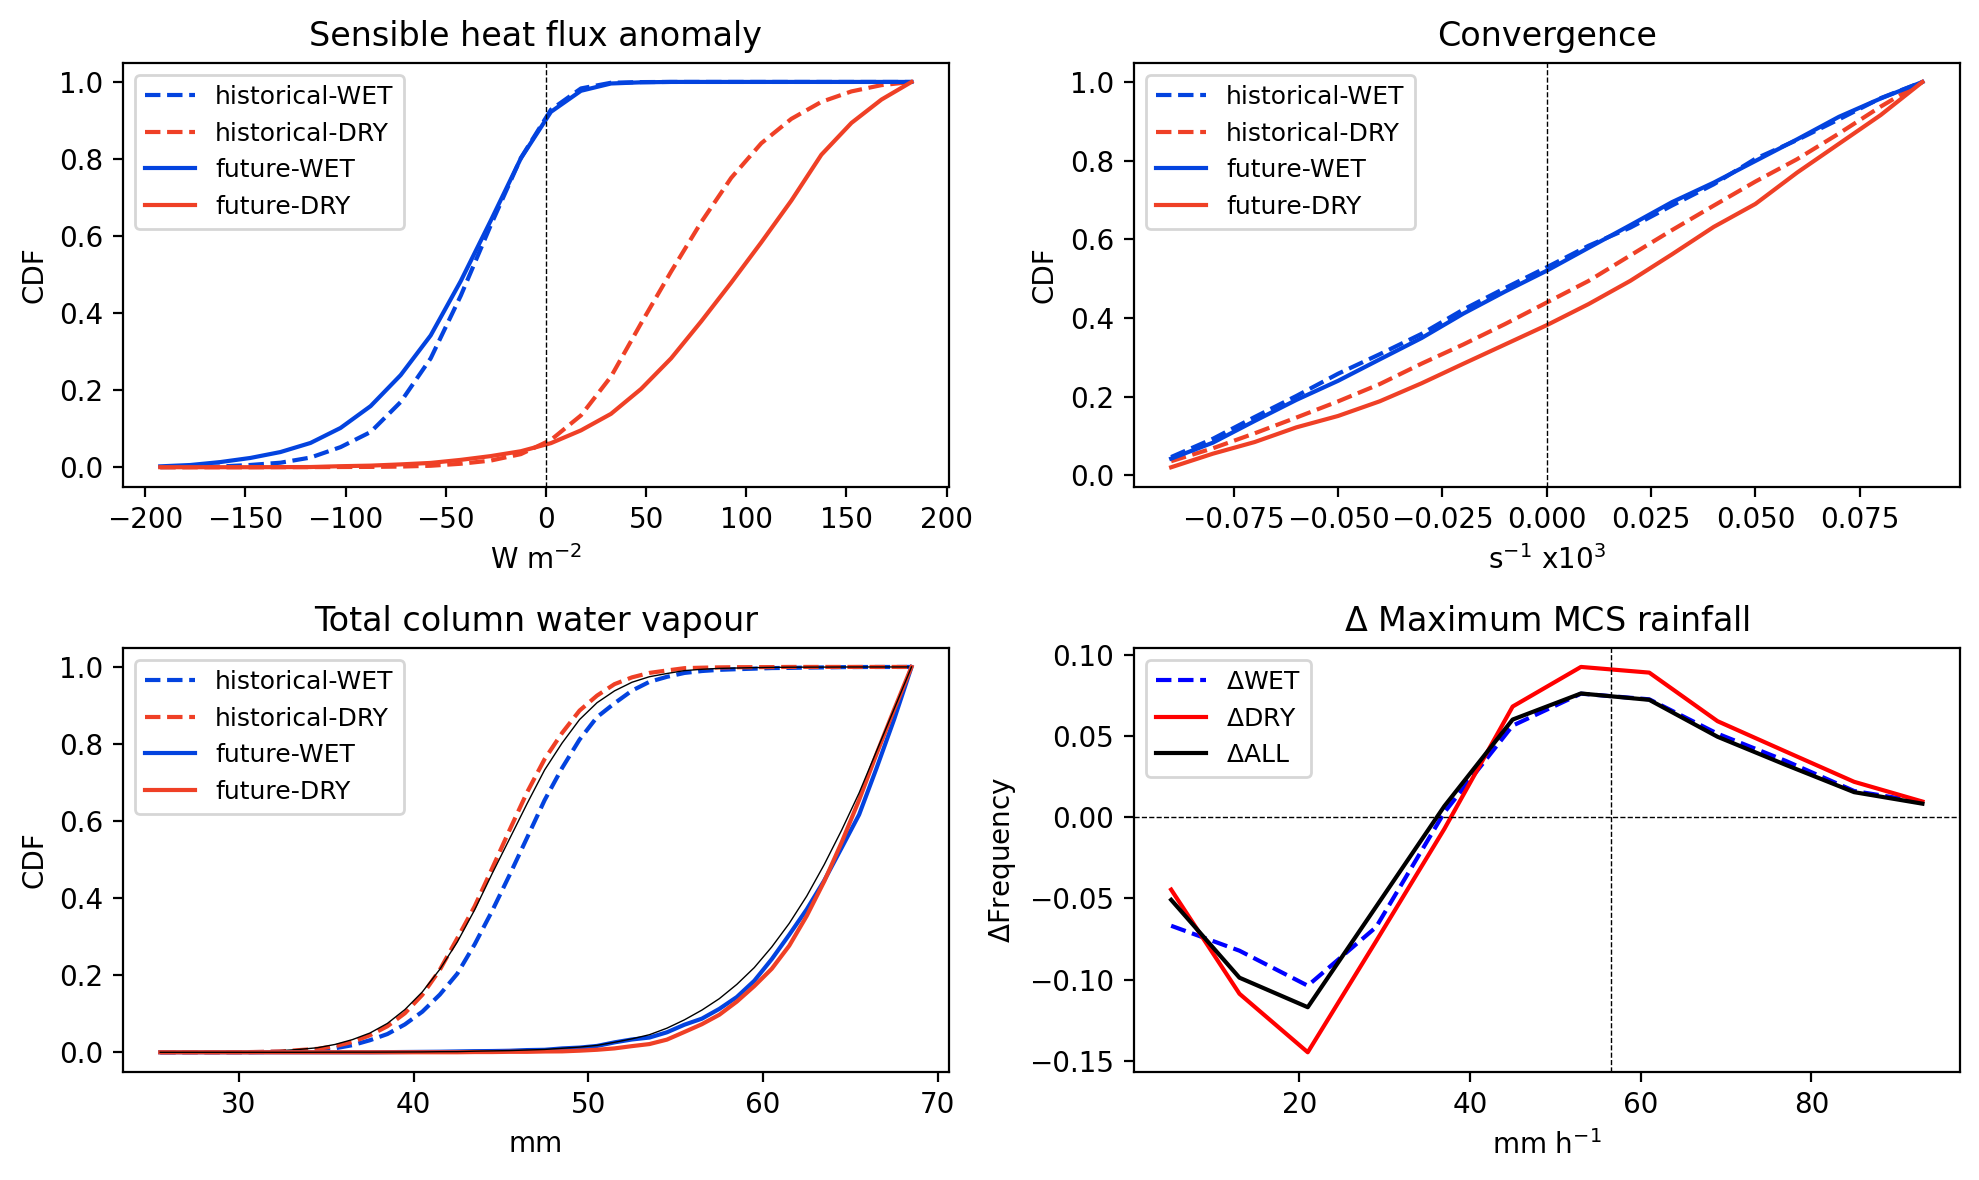

In [220]:
f = plt.figure(figsize=(10,6), dpi=200)



ax1 = f.add_subplot(221)

var = 'sh_1deg'
low = lahist[var][histposlow]
high = lahist[var][histposhigh]
alls = lahist[var]

flow = lafut[var][futposlow]
fhigh = lafut[var][futposhigh]
falls = lafut[var]


cp4 = hist2d.basic_1d_binning(low, np.arange(-200, 200,15))
cp4f = hist2d.basic_1d_binning(high, np.arange(-200, 200,15))
alle = hist2d.basic_1d_binning(alls, np.arange(-200, 200,15))

fcp4 = hist2d.basic_1d_binning(flow, np.arange(-200, 200,15))
fcp4f = hist2d.basic_1d_binning(fhigh, np.arange(-200, 200,15))
falle = hist2d.basic_1d_binning(falls, np.arange(-200, 200,15))



bins=cp4['xbins']

cumlow = np.cumsum(cp4['nb']/np.sum(cp4['nb']))
cumhigh = np.cumsum(cp4f['nb']/np.sum(cp4f['nb']))
cumall = np.cumsum(alle['nb']/np.sum(alle['nb']))

fcumlow = np.cumsum(fcp4['nb']/np.sum(fcp4['nb']))
fcumhigh = np.cumsum(fcp4f['nb']/np.sum(fcp4f['nb']))
fcumall = np.cumsum(falle['nb']/np.sum(falle['nb']))

# cumlow = (cp4['nb']/np.sum(cp4['nb']))
# cumhigh = (cp4f['nb']/np.sum(cp4f['nb']))
# cumall = (alle['nb']/np.sum(alle['nb']))

# fcumlow = (fcp4['nb']/np.sum(fcp4['nb']))
# fcumhigh = (fcp4f['nb']/np.sum(fcp4f['nb']))
# fcumall = (falle['nb']/np.sum(falle['nb']))

stat, pval = stats.mannwhitneyu(low, flow, nan_policy='omit')
print('t2 wet', stat,pval)
stat, pval = stats.mannwhitneyu(high, fhigh, nan_policy='omit')
print('t2 dry', stat,pval)

plt.plot(bins, cumlow, color='xkcd:blue', label='historical-WET', linestyle='dashed')
plt.plot(bins, cumhigh, color='xkcd:tomato', label='historical-DRY', linestyle='dashed')
#plt.plot(bins, cumall, color='k', label='future' )

plt.plot(bins, fcumlow, color='xkcd:blue', label='future-WET' )
plt.plot(bins, fcumhigh, color='xkcd:tomato', label='future-DRY' )
ax1.axvline(0, color='k', linestyle='dashed', linewidth=0.5)
#plt.plot(bins, fcumall, color='grey', label='future' )


plt.ylabel('CDF')
plt.xlabel('W m$^{-2}$')
plt.title('Sensible heat flux anomaly')
plt.legend(fontsize=9)
plt.legend(fontsize=9)


ax1 = f.add_subplot(222)

var = 'div'
### original divergence while rest is from old table
low = lahist[var][histposlow]*-10000
high = lahist[var][histposhigh]*-10000
alls = lahist[var]*-10000

flow = lafut[var][futposlow]*-10000
fhigh = lafut[var][futposhigh]*-10000
falls = lafut[var]*-10000


ranges = np.linspace(-0.1, 0.1,20)

cp4 = hist2d.basic_1d_binning(low, ranges)
cp4f = hist2d.basic_1d_binning(high, ranges)
alle = hist2d.basic_1d_binning(alls, ranges)

fcp4 = hist2d.basic_1d_binning(flow, ranges)
fcp4f = hist2d.basic_1d_binning(fhigh, ranges)
falle = hist2d.basic_1d_binning(falls, ranges)



bins=cp4['xbins']

cumlow = np.cumsum(cp4['nb']/np.sum(cp4['nb']))
cumhigh = np.cumsum(cp4f['nb']/np.sum(cp4f['nb']))
cumall = np.cumsum(alle['nb']/np.sum(alle['nb']))

fcumlow = np.cumsum(fcp4['nb']/np.sum(fcp4['nb']))
fcumhigh = np.cumsum(fcp4f['nb']/np.sum(fcp4f['nb']))
fcumall = np.cumsum(falle['nb']/np.sum(falle['nb']))

# cumlow = (cp4['nb']/np.sum(cp4['nb']))
# cumhigh = (cp4f['nb']/np.sum(cp4f['nb']))
# cumall = (alle['nb']/np.sum(alle['nb']))

# fcumlow = (fcp4['nb']/np.sum(fcp4['nb']))
# fcumhigh = (fcp4f['nb']/np.sum(fcp4f['nb']))
# fcumall = (falle['nb']/np.sum(falle['nb']))


stat, pval = stats.mannwhitneyu(low, flow, nan_policy='omit')
print('t2 wet', stat,pval)
stat, pval = stats.mannwhitneyu(high, fhigh, nan_policy='omit')
print('t2 dry', stat,pval)

plt.plot(bins, cumlow, color='xkcd:blue', label='historical-WET', linestyle='dashed')
plt.plot(bins, cumhigh, color='xkcd:tomato', label='historical-DRY', linestyle='dashed')
#plt.plot(bins, cumall, color='k', label='future' )

plt.plot(bins, fcumlow, color='xkcd:blue', label='future-WET' )
plt.plot(bins, fcumhigh, color='xkcd:tomato', label='future-DRY' )
#plt.plot(bins, fcumall, color='grey', label='future' )


plt.ylabel('CDF')
plt.xlabel('s$^{-1}$ x10$^{3}$')
plt.title('Convergence')
plt.legend(fontsize=9)
plt.legend(fontsize=9)
ax1.axvline(0, color='k', linestyle='dashed', linewidth=0.5)


ax1 = f.add_subplot(223)

var = 'tcwv_cl'
low = lahist[var][histposlow]
high = lahist[var][histposhigh]
alls = lahist[var]

flow = lafut[var][futposlow]
fhigh = lafut[var][futposhigh]
falls = lafut[var]


cp4 = hist2d.basic_1d_binning(low, np.arange(25, 70,1))
cp4f = hist2d.basic_1d_binning(high, np.arange(25, 70,1))
alle = hist2d.basic_1d_binning(alls, np.arange(25, 70,1))

fcp4 = hist2d.basic_1d_binning(flow, np.arange(25, 70,1))
fcp4f = hist2d.basic_1d_binning(fhigh, np.arange(25, 70,1))
falle = hist2d.basic_1d_binning(falls, np.arange(25, 70,1))

bins=cp4['xbins']

cumlow = np.cumsum(cp4['nb']/np.sum(cp4['nb']))
cumhigh = np.cumsum(cp4f['nb']/np.sum(cp4f['nb']))
cumall = np.cumsum(alle['nb']/np.sum(alle['nb']))

fcumlow = np.cumsum(fcp4['nb']/np.sum(fcp4['nb']))
fcumhigh = np.cumsum(fcp4f['nb']/np.sum(fcp4f['nb']))
fcumall = np.cumsum(falle['nb']/np.sum(falle['nb']))

# cumlow = (cp4['nb']/np.sum(cp4['nb']))
# cumhigh = (cp4f['nb']/np.sum(cp4f['nb']))
# cumall = (alle['nb']/np.sum(alle['nb']))

# fcumlow = (fcp4['nb']/np.sum(fcp4['nb']))
# fcumhigh = (fcp4f['nb']/np.sum(fcp4f['nb']))
# fcumall = (falle['nb']/np.sum(falle['nb']))

plt.plot(bins, cumlow, color='xkcd:blue', label='historical-WET', linestyle='dashed')
plt.plot(bins, cumhigh, color='xkcd:tomato', label='historical-DRY', linestyle='dashed')
plt.plot(bins, cumall, color='k', linewidth=0.5)

plt.plot(bins, fcumlow, color='xkcd:blue', label='future-WET' )
plt.plot(bins, fcumhigh, color='xkcd:tomato', label='future-DRY' )
plt.plot(bins, fcumall, color='k', linewidth=0.5)


plt.ylabel('CDF')
plt.xlabel('mm')
plt.title('Total column water vapour')
plt.legend(fontsize=9)
plt.legend(fontsize=9)




ax1 = f.add_subplot(224)

var = 'pmax'
low = lahist[var][histposlow]
high = lahist[var][histposhigh]
alls = lahist[var]

flow = lafut[var][futposlow]
fhigh = lafut[var][futposhigh]
falls = lafut[var]


cp4 = hist2d.basic_1d_binning(low, np.arange(1, 101,8))
cp4f = hist2d.basic_1d_binning(high, np.arange(1, 101,8))
alle = hist2d.basic_1d_binning(alls, np.arange(1, 101,8))

fcp4 = hist2d.basic_1d_binning(flow, np.arange(1, 101,8))
fcp4f = hist2d.basic_1d_binning(fhigh, np.arange(1, 101,8))
falle = hist2d.basic_1d_binning(falls, np.arange(1, 101,8))

print()



bins=cp4['xbins']

# cumlow = np.cumsum(cp4['nb']/np.sum(cp4['nb']))
# cumhigh = np.cumsum(cp4f['nb']/np.sum(cp4f['nb']))
# cumall = np.cumsum(alle['nb']/np.sum(alle['nb']))

# fcumlow = np.cumsum(fcp4['nb']/np.sum(fcp4['nb']))
# fcumhigh = np.cumsum(fcp4f['nb']/np.sum(fcp4f['nb']))
# fcumall = np.cumsum(falle['nb']/np.sum(falle['nb']))

cumlow = (cp4['nb']/np.sum(cp4['nb']))
cumhigh = (cp4f['nb']/np.sum(cp4f['nb']))
cumall = (alle['nb']/np.sum(alle['nb']))

fcumlow = (fcp4['nb']/np.sum(fcp4['nb']))
fcumhigh = (fcp4f['nb']/np.sum(fcp4f['nb']))
fcumall = (falle['nb']/np.sum(falle['nb']))

stat, pval = stats.mannwhitneyu(low, flow, nan_policy='omit')
print('t2 wet', stat,pval)
stat, pval = stats.mannwhitneyu(high, fhigh, nan_policy='omit')
print('t2 dry', stat,pval)

plt.plot(bins, fcumlow-cumlow, color='b', label='$\Delta$WET', linestyle='dashed')
plt.plot(bins, fcumhigh-cumhigh, color='r', label='$\Delta$DRY' )
plt.plot(bins, fcumall-cumall, color='k', label='$\Delta$ALL' )
# plt.plot(bins, cumlow, color='xkcd:blue', label='historical-WET', linestyle='dashed')
# plt.plot(bins, cumhigh, color='xkcd:tomato', label='historical-DRY', linestyle='dashed')
# plt.plot(bins, cumall, color='k', linewidth=0.5)

# plt.plot(bins, fcumlow, color='xkcd:blue', label='future-WET' )
# plt.plot(bins, fcumhigh, color='xkcd:tomato', label='future-DRY' )
# plt.plot(bins, fcumall, color='k', linewidth=0.5)

#plt.plot(bins, fcumhigh, color='xkcd:tomato', label='future-DRY' )
# plt.plot(bins, fcumall, color='k', linewidth=0.5)
# plt.plot(bins, cumall, color='k', label='all cases', linewidth=0.5)

print('allcase difference', np.nanmean(falls)-np.nanmean(alls))
print('drycase difference', np.nanmean(fhigh)-np.nanmean(high))

print('allcase difference rel to hist', (np.nanmean(falls)-np.nanmean(alls))/np.nanmean(alls))
print('drycase difference rel to hist', (np.nanmean(fhigh)-np.nanmean(high))/np.nanmean(high))

plt.ylabel('$\Delta$Frequency')
plt.xlabel('mm h$^{-1}$')
plt.title('$\Delta$ Maximum MCS rainfall')
ax1.axhline(0,linestyle='dashed', color='k', linewidth=0.5)
#ax1.axvline(np.nanpercentile(high, 95), linestyle='dashed', color='r', linewidth=0.5)
#ax1.axvline(np.nanpercentile(low, 95), linestyle='dashed', color='b', linewidth=0.5)
ax1.axvline(np.nanpercentile(alls, 99), linestyle='dashed', color='k', linewidth=0.5)
p99 = np.percentile(alls,99)
print('Hist p99')
print(np.sum(alls>p99)/alls.size*100) #- np.sum(alls>p99)/alls.size)
print(np.sum(low>p99)/low.size*100)
print(np.sum(high>p99)/high.size*100)
print('Hist p99 in future')
print(np.sum(falls>p99)/falls.size*100)
print(np.sum(flow>p99)/flow.size*100)
print(np.sum(fhigh>p99)/fhigh.size*100)
print('Hist p99 in fut versus in hist')
print(np.sum(falls>p99)/falls.size*100 - np.sum(alls>p99)/alls.size*100) #- np.sum(alls>p99)/alls.size)
print(np.sum(flow>p99)/flow.size*100 - np.sum(low>p99)/low.size*100)
print(np.sum(fhigh>p99)/fhigh.size*100 - np.sum(high>p99)/high.size*100)

print('Mean rainfall increase')
# print((np.percentile(falls, 90)-np.percentile(alls, 90)))
# print((np.percentile(flow, 90)-np.percentile(low, 90)))
# print((np.percentile(fhigh, 90)-np.percentile(high, 90)))
pp = 50
print('Percentile')
print((np.percentile(falls, pp)-np.percentile(alls, pp))/np.percentile(alls, pp))
print((np.percentile(flow, pp)-np.percentile(low, pp))/np.percentile(low, pp))
print((np.percentile(fhigh, pp)-np.percentile(high, pp))/np.percentile(high, pp))

print(np.percentile(alls, 90))
print(np.percentile(low, 90))
print(np.percentile(high, 90))

print('Mean diff')
print((np.mean(falls)-np.mean(alls))/np.mean(alls))
print((np.mean(flow)-np.mean(low))/np.mean(low))
print((np.mean(fhigh)-np.mean(high))/np.mean(high))

print('mean')
print(np.mean(alls))
print(np.mean(low))
print(np.mean(high))


plt.legend(fontsize=9)
plt.legend(fontsize=9)

plt.tight_layout()
#f.savefig('fig2_divergence.jpg'), 

<>:203: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:204: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:205: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:203: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:204: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:205: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
/tmp/ipykernel_332/3508085619.py:203: SyntaxWarning: "\D" is an invali

t2 wet 1399212.0 0.7233867308931203
t2 dry 832878.0 2.053202460447092e-93
t2 wet 1451172.0 0.1350186893860552
t2 dry 844636.0 1.0186248571330175e-89
t2 wet 1036702.0 3.0093775078791496e-40
t2 dry 1023495.5 7.503664289472714e-43
t2 wet 890956.0 6.746238887290317e-76
t2 dry 720243.0 1.1697655997839867e-132
allcase difference 13.474962932076345
drycase difference 15.56826005039612
allcase difference rel to hist 0.6278434376015288
drycase difference rel to hist 0.6468867986769459


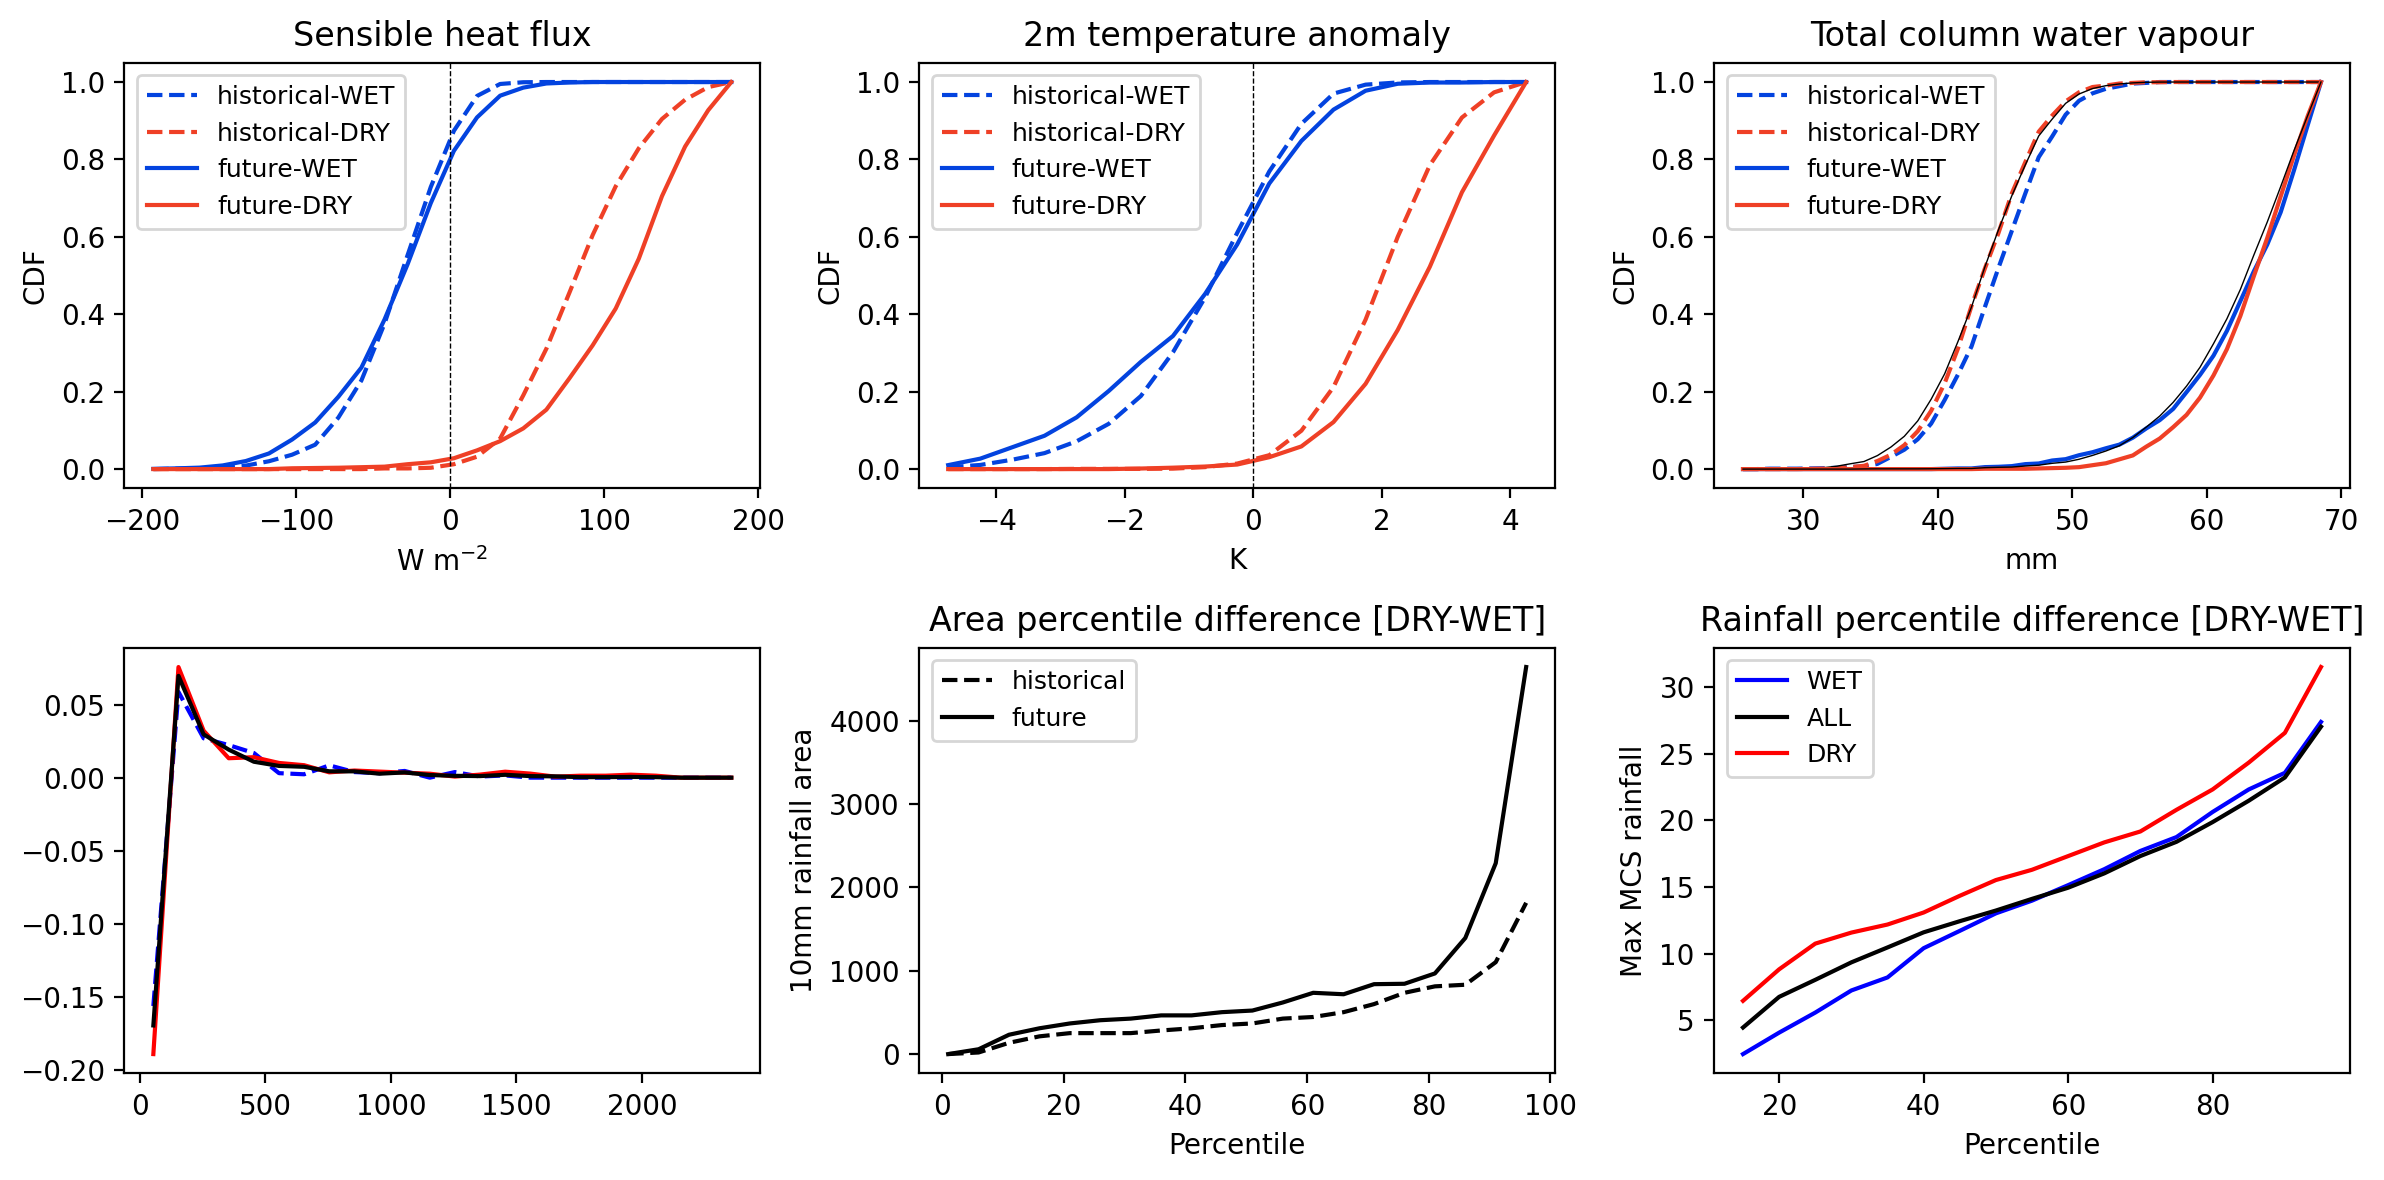

In [185]:
f = plt.figure(figsize=(12,6), dpi=200)



ax1 = f.add_subplot(231)

var = 'sh_1deg'
low = lahist[var][histposlow]
high = lahist[var][histposhigh]
alls = lahist[var]

flow = lafut[var][futposlow]
fhigh = lafut[var][futposhigh]
falls = lafut[var]


cp4 = hist2d.basic_1d_binning(low, np.arange(-200, 200,15))
cp4f = hist2d.basic_1d_binning(high, np.arange(-200, 200,15))
alle = hist2d.basic_1d_binning(alls, np.arange(-200, 200,15))

fcp4 = hist2d.basic_1d_binning(flow, np.arange(-200, 200,15))
fcp4f = hist2d.basic_1d_binning(fhigh, np.arange(-200, 200,15))
falle = hist2d.basic_1d_binning(falls, np.arange(-200, 200,15))



bins=cp4['xbins']

cumlow = np.cumsum(cp4['nb']/np.sum(cp4['nb']))
cumhigh = np.cumsum(cp4f['nb']/np.sum(cp4f['nb']))
cumall = np.cumsum(alle['nb']/np.sum(alle['nb']))

fcumlow = np.cumsum(fcp4['nb']/np.sum(fcp4['nb']))
fcumhigh = np.cumsum(fcp4f['nb']/np.sum(fcp4f['nb']))
fcumall = np.cumsum(falle['nb']/np.sum(falle['nb']))

stat, pval = stats.mannwhitneyu(low, flow, nan_policy='omit')
print('t2 wet', stat,pval)
stat, pval = stats.mannwhitneyu(high, fhigh, nan_policy='omit')
print('t2 dry', stat,pval)

plt.plot(bins, cumlow, color='xkcd:blue', label='historical-WET', linestyle='dashed')
plt.plot(bins, cumhigh, color='xkcd:tomato', label='historical-DRY', linestyle='dashed')
#plt.plot(bins, cumall, color='k', label='future' )

plt.plot(bins, fcumlow, color='xkcd:blue', label='future-WET' )
plt.plot(bins, fcumhigh, color='xkcd:tomato', label='future-DRY' )
ax1.axvline(0, color='k', linestyle='dashed', linewidth=0.5)
#plt.plot(bins, fcumall, color='grey', label='future' )


plt.ylabel('CDF')
plt.xlabel('W m$^{-2}$')
plt.title('Sensible heat flux')
plt.legend(fontsize=9)
plt.legend(fontsize=9)


ax1 = f.add_subplot(232)

var = 't2_1deg'
low = lahist[var][histposlow]
high = lahist[var][histposhigh]
alls = lahist[var]

flow = lafut[var][futposlow]
fhigh = lafut[var][futposhigh]
falls = lafut[var]


cp4 = hist2d.basic_1d_binning(low, np.arange(-5, 5,0.5))
cp4f = hist2d.basic_1d_binning(high, np.arange(-5, 5,0.5))
alle = hist2d.basic_1d_binning(alls, np.arange(-5, 5,0.5))

fcp4 = hist2d.basic_1d_binning(flow, np.arange(-5, 5,0.5))
fcp4f = hist2d.basic_1d_binning(fhigh, np.arange(-5, 5,0.5))
falle = hist2d.basic_1d_binning(falls, np.arange(-5, 5,0.5))



bins=cp4['xbins']

cumlow = np.cumsum(cp4['nb']/np.sum(cp4['nb']))
cumhigh = np.cumsum(cp4f['nb']/np.sum(cp4f['nb']))
cumall = np.cumsum(alle['nb']/np.sum(alle['nb']))

fcumlow = np.cumsum(fcp4['nb']/np.sum(fcp4['nb']))
fcumhigh = np.cumsum(fcp4f['nb']/np.sum(fcp4f['nb']))
fcumall = np.cumsum(falle['nb']/np.sum(falle['nb']))

stat, pval = stats.mannwhitneyu(low, flow, nan_policy='omit')
print('t2 wet', stat,pval)
stat, pval = stats.mannwhitneyu(high, fhigh, nan_policy='omit')
print('t2 dry', stat,pval)

plt.plot(bins, cumlow, color='xkcd:blue', label='historical-WET', linestyle='dashed')
plt.plot(bins, cumhigh, color='xkcd:tomato', label='historical-DRY', linestyle='dashed')
#plt.plot(bins, cumall, color='k', label='future' )

plt.plot(bins, fcumlow, color='xkcd:blue', label='future-WET' )
plt.plot(bins, fcumhigh, color='xkcd:tomato', label='future-DRY' )
#plt.plot(bins, fcumall, color='grey', label='future' )


plt.ylabel('CDF')
plt.xlabel('K')
plt.title('2m temperature anomaly')
plt.legend(fontsize=9)
plt.legend(fontsize=9)
ax1.axvline(0, color='k', linestyle='dashed', linewidth=0.5)


ax1 = f.add_subplot(233)

var = 'tcwv_cl'
low = lahist[var][histposlow]
high = lahist[var][histposhigh]
alls = lahist[var]

flow = lafut[var][futposlow]
fhigh = lafut[var][futposhigh]
falls = lafut[var]


cp4 = hist2d.basic_1d_binning(low, np.arange(25, 70,1))
cp4f = hist2d.basic_1d_binning(high, np.arange(25, 70,1))
alle = hist2d.basic_1d_binning(alls, np.arange(25, 70,1))

fcp4 = hist2d.basic_1d_binning(flow, np.arange(25, 70,1))
fcp4f = hist2d.basic_1d_binning(fhigh, np.arange(25, 70,1))
falle = hist2d.basic_1d_binning(falls, np.arange(25, 70,1))

bins=cp4['xbins']

cumlow = np.cumsum(cp4['nb']/np.sum(cp4['nb']))
cumhigh = np.cumsum(cp4f['nb']/np.sum(cp4f['nb']))
cumall = np.cumsum(alle['nb']/np.sum(alle['nb']))

fcumlow = np.cumsum(fcp4['nb']/np.sum(fcp4['nb']))
fcumhigh = np.cumsum(fcp4f['nb']/np.sum(fcp4f['nb']))
fcumall = np.cumsum(falle['nb']/np.sum(falle['nb']))

plt.plot(bins, cumlow, color='xkcd:blue', label='historical-WET', linestyle='dashed')
plt.plot(bins, cumhigh, color='xkcd:tomato', label='historical-DRY', linestyle='dashed')
plt.plot(bins, cumall, color='k', linewidth=0.5)

plt.plot(bins, fcumlow, color='xkcd:blue', label='future-WET' )
plt.plot(bins, fcumhigh, color='xkcd:tomato', label='future-DRY' )
plt.plot(bins, fcumall, color='k', linewidth=0.5)


plt.ylabel('CDF')
plt.xlabel('mm')
plt.title('Total column water vapour')
plt.legend(fontsize=9)
plt.legend(fontsize=9)


ax1 = f.add_subplot(234)

var = 'area_10mm'
low = lahist[var][histposlow]
high = lahist[var][histposhigh]
alls = lahist[var]

flow = lafut[var][futposlow]
fhigh = lafut[var][futposhigh]
falls = lafut[var]


cp4 = hist2d.basic_1d_binning(low, np.arange(5, 2500,100))
cp4f = hist2d.basic_1d_binning(high, np.arange(5, 2500,100))
alle = hist2d.basic_1d_binning(alls, np.arange(5, 2500,100))

fcp4 = hist2d.basic_1d_binning(flow, np.arange(5, 2500,100))
fcp4f = hist2d.basic_1d_binning(fhigh, np.arange(5, 2500,100))
falle = hist2d.basic_1d_binning(falls, np.arange(5, 2500,100))

#ax1.set_yscale("log")   # log y-axis
bins=cp4['xbins']

# cumlow = np.cumsum(cp4['nb']/np.sum(cp4['nb']))
# cumhigh = np.cumsum(cp4f['nb']/np.sum(cp4f['nb']))
# cumall = np.cumsum(alle['nb']/np.sum(alle['nb']))

# fcumlow = np.cumsum(fcp4['nb']/np.sum(fcp4['nb']))
# fcumhigh = np.cumsum(fcp4f['nb']/np.sum(fcp4f['nb']))
# fcumall = np.cumsum(falle['nb']/np.sum(falle['nb']))

cumlow = (cp4['nb']/np.sum(cp4['nb']))
cumhigh = (cp4f['nb']/np.sum(cp4f['nb']))
cumall = (alle['nb']/np.sum(alle['nb']))

fcumlow = (fcp4['nb']/np.sum(fcp4['nb']))
fcumhigh = (fcp4f['nb']/np.sum(fcp4f['nb']))
fcumall = (falle['nb']/np.sum(falle['nb']))

stat, pval = stats.mannwhitneyu(low, flow, nan_policy='omit')
print('t2 wet', stat,pval)
stat, pval = stats.mannwhitneyu(high, fhigh, nan_policy='omit')
print('t2 dry', stat,pval)

plt.plot(bins, fcumlow-cumlow, color='b', label='$\Delta$WET', linestyle='dashed')
plt.plot(bins, fcumhigh-cumhigh, color='r', label='$\Delta$DRY' )
plt.plot(bins, fcumall-cumall, color='k', label='$\Delta$ALL' )


ax = f.add_subplot(235)

var = 'area_10mm'
low = lahist[var][histposlow]*(4.4*4.4)
high = lahist[var][histposhigh]*(4.4*4.4)
alls = lahist[var]*(4.4*4.4)

flow = lafut[var][futposlow]*(4.4*4.4)
fhigh = lafut[var][futposhigh]*(4.4*4.4)
falls = lafut[var]*(4.4*4.4)


cp4 = hist2d.basic_1d_binning(low, np.arange(5, 2500,100))
cp4f = hist2d.basic_1d_binning(high, np.arange(5, 2500,100))
alle = hist2d.basic_1d_binning(alls, np.arange(5, 2500,100))

fcp4 = hist2d.basic_1d_binning(flow, np.arange(5, 2500,100))
fcp4f = hist2d.basic_1d_binning(fhigh, np.arange(5, 2500,100))
falle = hist2d.basic_1d_binning(falls, np.arange(5, 2500,100))


bins=cp4['xbins']

cumlow = np.percentile(low, np.arange(1,99,5))
cumhigh = np.percentile(high, np.arange(1,99,5))
cumall = np.percentile(alls, np.arange(1,99,5))

fcumlow = np.percentile(flow, np.arange(1,99,5))
fcumhigh = np.percentile(fhigh, np.arange(1,99,5))
fcumall =  np.percentile(falls, np.arange(1,99,5))


plt.plot(np.arange(1,99,5), cumhigh-cumlow, color='k', label='historical', linestyle='dashed')
#plt.plot(np.arange(0,101,5), cumhigh, color='xkcd:tomato', label='historical-DRY', linestyle='dashed')


plt.plot(np.arange(1,99,5), fcumhigh-fcumlow, color='k', label='future' )
#plt.plot(np.arange(0,101,5), fcumhigh, color='xkcd:tomato', label='future-DRY' )

plt.ylabel('10mm rainfall area')
plt.xlabel('Percentile')
plt.title('Area percentile difference [DRY-WET]')

plt.legend(fontsize=9)



ax1 = f.add_subplot(236)

var = 'pmax'
low = lahist[var][histposlow]
high = lahist[var][histposhigh]
alls = lahist[var]

flow = lafut[var][futposlow]
fhigh = lafut[var][futposhigh]
falls = lafut[var]


# cp4 = hist2d.basic_1d_binning(low, np.arange(1, 75,1))
# cp4f = hist2d.basic_1d_binning(high, np.arange(1, 75,1))
# alle = hist2d.basic_1d_binning(alls, np.arange(1, 75,1))

# fcp4 = hist2d.basic_1d_binning(flow, np.arange(1, 75,1))
# fcp4f = hist2d.basic_1d_binning(fhigh, np.arange(1, 75,1))
# falle = hist2d.basic_1d_binning(falls, np.arange(1, 75,1))



bins=cp4['xbins']

cumlow = np.percentile(low, np.arange(0,101,5))
cumhigh = np.percentile(high, np.arange(0,101,5))
cumall = np.percentile(alls, np.arange(0,101,5))

fcumlow = np.percentile(flow, np.arange(0,101,5))
fcumhigh = np.percentile(fhigh, np.arange(0,101,5))
fcumall =  np.percentile(falls, np.arange(0,101,5))

stat, pval = stats.mannwhitneyu(low, flow, nan_policy='omit')
print('t2 wet', stat,pval)
stat, pval = stats.mannwhitneyu(high, fhigh, nan_policy='omit')
print('t2 dry', stat,pval)

plt.plot(np.arange(0,101,5)[3:-1], ((fcumlow-cumlow))[3:-1], color='blue', label='WET', linestyle='solid')
#plt.plot(np.arange(0,101,5)[0:-1], cumhigh, color='xkcd:tomato', label='historical-DRY', linestyle='dashed')
plt.plot(np.arange(0,101,5)[3:-1], ((fcumall-cumall))[3:-1], color='k', label='ALL' )
plt.plot(np.arange(0,101,5)[3:-1], ((fcumhigh-cumhigh))[3:-1], color='red', label='DRY' )
#plt.plot(np.arange(0,101,5), fcumhigh, color='xkcd:tomato', label='future-DRY' )
# plt.plot(bins, fcumall, color='k', linewidth=0.5)
# plt.plot(bins, cumall, color='k', label='all cases', linewidth=0.5)

print('allcase difference', np.nanmean(falls)-np.nanmean(alls))
print('drycase difference', np.nanmean(fhigh)-np.nanmean(high))

print('allcase difference rel to hist', (np.nanmean(falls)-np.nanmean(alls))/np.nanmean(alls))
print('drycase difference rel to hist', (np.nanmean(fhigh)-np.nanmean(high))/np.nanmean(high))

plt.ylabel('Max MCS rainfall')
plt.xlabel('Percentile')
plt.title('Rainfall percentile difference [DRY-WET]')
plt.legend(fontsize=9)
plt.legend(fontsize=9)

plt.tight_layout()
#f.savefig(cnst.network_data + 'figs/LMCS/CP4_PNASstudy/SHsplit_variable_distributions_100km-Box.jpg')

In [117]:
lafut['area_10mm'].max()

2681.0

In [22]:
import scipy.stats as stats
from scipy.stats import gaussian_kde, linregress
def calc_density(v1,v2):

    xy = np.vstack([v1, v2])

    z = gaussian_kde(xy)(xy)

    return z / (z.max() - z.min())

# cp4s = [lhist[var2], lhist[var]] 
# finites = np.isfinite(cp4s[0])&np.isfinite(cp4s[1])
# cp4s = [(cp4s[0])[finites],(cp4s[1])[finites]]
# r = stats.pearsonr(cp4s[0], cp4s[1])
# density = calc_density(cp4s[0], cp4s[1])
# plt.scatter(cp4s[0], cp4s[1], c=density, cmap='viridis')

# cp4s = [lfut[var2], lfut[var]] 
# finites = np.isfinite(cp4s[0])&np.isfinite(cp4s[1])
# cp4s = [(cp4s[0])[finites],(cp4s[1])[finites]]
# r = stats.pearsonr(cp4s[0], cp4s[1])
# density = calc_density(cp4s[0], cp4s[1])
# plt.scatter(cp4s[0], cp4s[1], c=density, cmap='inferno', alpha=0.3)

In [23]:
from scipy.stats import binned_statistic
def binning(dic, var1, var2, bins):
    func = lambda y: np.nanmean(y)   #  could also be np.percentile(y, 95) etc.
    #func = lambda y: np.nanpercentile(y, 95)  #  could also be np.percentile(y, 95) etc.
    dat, bin_edges, binnumber = binned_statistic(dic[var1], dic[var2], statistic=func, bins=bins)
    tcbins = bin_edges[0:-1] + (bin_edges[1::]-bin_edges[0:-1])/2
  #  ipdb.set_trace()
    pslope, pintercept, pr_value, pp_value, pstd_err = stats.linregress(tcbins[np.isfinite(dat)], dat[np.isfinite(dat)])

    return dat, tcbins, pslope, pintercept, pp_value

In [24]:
len(lahist['lsRain_1deg'])

4712

In [25]:
len(lhist['lsRain_1deg'])

4966

pmax
sh_1deg
tcwv_1deg
pmax
sh_1deg
tcwv_1deg


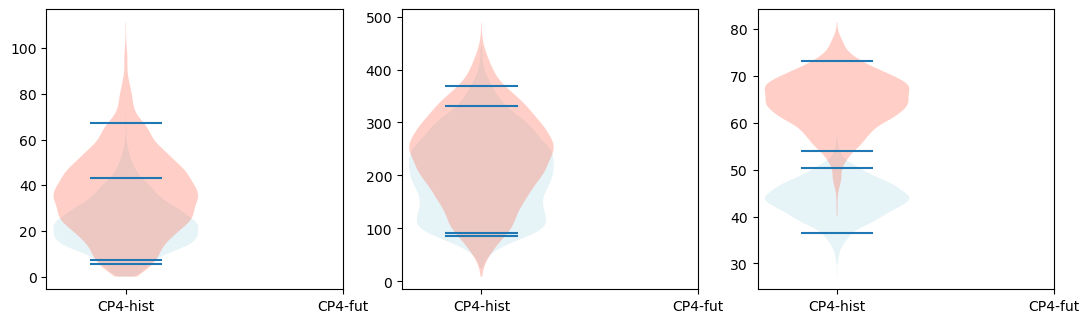

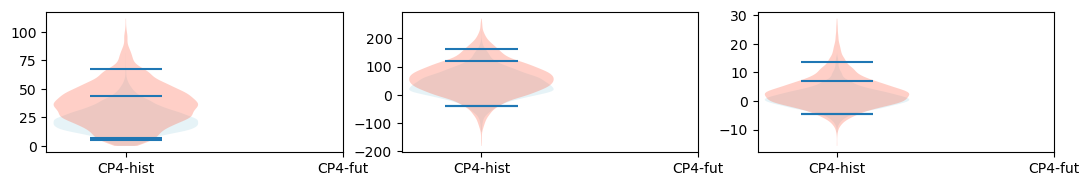

In [28]:
f= plt.figure(figsize=(13,8), dpi=100)
for idx, v in enumerate(['pmax', 'sh_1deg', 'tcwv_1deg']):

    dat1=lhist[v].dropna()
    dat2 = lfut[v].dropna()
    
    data = [dat1, dat2]
    print(v)
    
   # ipdb.set_trace()

    labels = ['CP4-hist', 'CP4-fut']
    
    bpos = np.linspace(0.25,1,len(labels))

    ax = f.add_subplot(2,3,idx+1)
    parts = ax.violinplot(data, positions=[0.25,0.25], showmeans=False, showextrema=False, quantiles=[[0.05,0.95], [0.05,0.95]]) # positions=bpos, whis=[10,90], patch_artist=True, widths=0.1, sym='.', medianprops=dict(color='k'), flierprops=dict(markersize=1)#
    
    (parts['bodies'][0]).set_facecolor('lightblue')
    (parts['bodies'][1]).set_facecolor('tomato')

    (parts['cquantiles']).set_facecolor('k')
    #(parts['cquantiles'][1]).set_facecolor('red')
    
    ax.set_xticks([0.25,1], labels=labels)
    
f= plt.figure(figsize=(13,4), dpi=100)
for idx, v in enumerate(['pmax', 'sh_1deg', 'tcwv_1deg']):

    dat1=lahist[v].dropna()
    dat2 = lafut[v].dropna()
    
    data = [dat1, dat2]
    print(v)
    
   # ipdb.set_trace()

    labels = ['CP4-hist', 'CP4-fut']
    
    bpos = np.linspace(0.25,1,len(labels))

    ax = f.add_subplot(2,3,idx+4)
    parts = ax.violinplot(data, positions=[0.25,0.25], showmeans=False, showextrema=False, quantiles=[[0.05,0.95], [0.05,0.95]]) # positions=bpos, whis=[10,90], patch_artist=True, widths=0.1, sym='.', medianprops=dict(color='k'), flierprops=dict(markersize=1)#
    
    (parts['bodies'][0]).set_facecolor('lightblue')
    (parts['bodies'][1]).set_facecolor('tomato')

    (parts['cquantiles']).set_facecolor('k')
    #(parts['cquantiles'][1]).set_facecolor('red')
    
    ax.set_xticks([0.25,1], labels=labels)

In [91]:
f= plt.figure(figsize=(13,8), dpi=100)
collect = []
varts = ['q_srfc_1deg', 'tcwv_1deg', 't_srfc_1deg', 'lh_1deg', 'sh_1deg', 'theta', 'theta-e']
for idx, v in enumerate(varts):
    efhist = lhist['EF']<0.75
    effut = lfut['EF']<0.75
    climhist=np.nanmean((lhist[v])[efhist].dropna())
    climfut= np.nanmean((lfut[v])[effut].dropna())
    
    anohist = np.mean(lahist[v].dropna())
    anofut= np.mean(lafut[v].dropna())
    
    print(v, climfut-climhist, anofut-anohist)
    

    
    
    anomcont = (anofut-anohist)/(climfut-climhist)*100
    
    collect.append(anomcont)
#ipdb.set_trace()

plt.bar(np.arange(len(varts)), height=collect, tick_label=varts)

q_srfc_1deg 4.757055060584312 0.1864867033865003
tcwv_1deg 20.949189811542922 2.6827549918068216
t_srfc_1deg 6.179659242534111 0.24730639109795716
lh_1deg -63.20148699077228 -36.43657706748158
sh_1deg 23.85155371519815 17.664026180689206


KeyError: 'theta'

<Figure size 1300x800 with 0 Axes>